# Truncated-Normal Plug-in Survival Comparisons with IPCW-Initial HAL-TMLE

This notebook separates the no-undersmoothing and undersmoothing versions of `CV-IPCW-L1MLE` for survival, and compares two CVL1MLE anchoring pipelines.

Objects compared in this notebook:

1. Plug-in estimators for density and baseline survival: `CV-IPCW`, `CV-IPCW-L1MLE`, `CV-IPCW + CVL1MLE`, and `CV-IPCW-L1MLE + CVL1MLE`
2. A separate survival-only estimator: `Plug-in undersmoothed CV-IPCW-L1MLE`
3. The only TMLE curve: `TMLE-CV-IPCW`

`CV-IPCW-L1MLE` means the direct plug-in fit at factor `1.0` on the post-`CV-IPCW` `L1MLE` path.
`Plug-in undersmoothed CV-IPCW-L1MLE` means we start from that same path, undersmooth along the path using the iterative-TMLE EIF rule, then plug the selected fit into survival estimation.
`CV-IPCW + CVL1MLE` means the existing package `RightCensoredObservedL1Tuner` anchored directly at Stage-1 `CV-IPCW`.
`CV-IPCW-L1MLE + CVL1MLE` means we first build `CV-IPCW-L1MLE` at factor `1.0`, then use that fit as the anchor for `RightCensoredObservedL1Tuner`.
`TMLE-CV-IPCW` is the only targeted survival procedure in this notebook.

The data-generating process is a truncated normal event-time law on `[0, 1]` with independent uniform censoring.


## Run Configuration

The next code cell keeps the main settings in one place.

Important knobs:

- `REPRESENTATIVE_SEED` controls the detailed single-run demo,
- `SMALL_MC_N_SEEDS = 50` and `N_WORKERS = 8` control the Monte Carlo comparison,
- `POST_IPCW_NORM_FACTORS` is the common norm-factor grid,
- `TARGETING_GRID` is `0.05, 0.10, ..., 0.95` inclusive,
- density panels use plug-in nuisance densities only and include `CV-IPCW`, `CV-IPCW-L1MLE`, `CV-IPCW + CVL1MLE`, and `CV-IPCW-L1MLE + CVL1MLE`,
- survival panels include those plug-in estimators plus `Plug-in undersmoothed CV-IPCW-L1MLE`, and TMLE only for Stage-1 `CV-IPCW`.

So the small-MC section reports plug-in nuisance diagnostics together with the IPCW-initial HAL-TMLE survival comparison.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from sklearn.model_selection import KFold

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right import (
    KaplanMeier,
    RightCensoredObservedL1MLE,
    right_censored_observed_loglik_and_gradient,
)
from haldensity.censoring.right.comparison import evaluate_survival_on_grid
from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.metrics import incomplete_loglik, ipcw_loglik
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.tuners.right_tuners import (
    RightCensoredInitTuner,
    RightCensoredObservedL1Tuner,
)
from haldensity.targeting.right_censored_survival.learner import right_censored_survival_targeting_M_step_v2
from haldensity.utils import TruncatedNormal

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPRESENTATIVE_SEED = 3

N = 200
CV_FOLDS = 5
N_TRIALS = 25
N_GRID_POINTS = 200

POST_IPCW_NORM_FACTORS = [float(x) for x in np.round(np.linspace(1.0, 2.0, 11), 2)]
TARGETING_GRID = np.round(np.linspace(0.05, 0.95, 19), 2)
CVLL_GRID_BY_BASIS_ORDER = {
    0: [float(x) for x in np.round(np.linspace(1.0, 15.0, 8), 2)],
    1: [float(x) for x in np.round(np.linspace(20.0, 80.0, 20), 2)],
    2: [float(x) for x in np.round(np.linspace(20.0, 100.0, 20), 2)],
}

SMALL_MC_N_SEEDS = 50
SMALL_MC_SEEDS = list(range(1, SMALL_MC_N_SEEDS + 1))
N_WORKERS = 8

SCORE_N_DIRECTIONS = 40
SCORE_QUADRATURE_N = 2001
SCORE_SEED_MULTIPLIER = 100

REFERENCE_TRUNCATED_NORMAL = {
    "mean": 0.5,
    "std": 0.15,
    "lower": 0.0,
    "upper": 1.0,
}

STAGE1_OVERRIDES = {
    "basis_order": [0, 1, 2],
    "norm_constraint": {"low": 1.0, "high": 250.0, "log": False},
}

OBSERVED_L1_KWARGS = {
    "n_grid_points": N_GRID_POINTS,
    "learning_rate": 0.1,
    "n_iterations": 30000,
    "ll_change_tol": 1e-4,
    "include_intercept_in_constraint": False,
    "history_every": 100,
}

TARGETING_KWARGS = {
    "mode": "iterative",
    "clip": 1e-6,
    "survival_clip": 1e-8,
    "max_iter": 25,
    "min_abs_eps": 1e-10,
    "min_score_tol": 1e-8,
    "store_pointwise_arrays": False,
}

CV_IPCW_METHOD = "CV-IPCW"
TMLE_CV_IPCW_METHOD = "TMLE-CV-IPCW"
CV_IPCW_L1MLE_METHOD = "CV-IPCW-L1MLE"
US_CV_IPCW_L1MLE_METHOD = "Plug-in undersmoothed CV-IPCW-L1MLE"
CVL1MLE_METHOD = "CV-IPCW + CVL1MLE"
CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD = "CV-IPCW-L1MLE + CVL1MLE"

RUNTIME_METHOD_ORDER = [
    CV_IPCW_METHOD,
    TMLE_CV_IPCW_METHOD,
    CV_IPCW_L1MLE_METHOD,
    US_CV_IPCW_L1MLE_METHOD,
    CVL1MLE_METHOD,
    CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
]
SURVIVAL_METHOD_ORDER = [
    CV_IPCW_METHOD,
    TMLE_CV_IPCW_METHOD,
    CV_IPCW_L1MLE_METHOD,
    US_CV_IPCW_L1MLE_METHOD,
    CVL1MLE_METHOD,
    CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
]
DENSITY_METHOD_ORDER = [
    CV_IPCW_METHOD,
    CV_IPCW_L1MLE_METHOD,
    CVL1MLE_METHOD,
    CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
]

run_config = pd.DataFrame(
    [
        {
            "representative_seed": REPRESENTATIVE_SEED,
            "n": N,
            "cv_folds": CV_FOLDS,
            "stage1_n_trials": N_TRIALS,
            "small_mc_n_seeds": SMALL_MC_N_SEEDS,
            "small_mc_n_workers": N_WORKERS,
            "dgp": "TruncatedNormal(mean=0.5, std=0.15) + Uniform censoring",
            "factor_grid": ", ".join(f"{x:.2f}" for x in POST_IPCW_NORM_FACTORS),
            "targeting_grid": "0.05:0.95:0.05 (inclusive, 19 points)",
            "cvll_grid_by_basis_order": "; ".join(
                f"k={k}: " + ", ".join(f"{value:.2f}" for value in values)
                for k, values in CVLL_GRID_BY_BASIS_ORDER.items()
            ),
            "targeting_mode": TARGETING_KWARGS["mode"],
            "targeting_max_iter": TARGETING_KWARGS["max_iter"],
            "score_n_directions": SCORE_N_DIRECTIONS,
            "score_quadrature_n": SCORE_QUADRATURE_N,
        }
    ]
)
display(run_config)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,representative_seed,n,cv_folds,stage1_n_trials,small_mc_n_seeds,small_mc_n_workers,dgp,factor_grid,targeting_grid,cvll_grid_by_basis_order,targeting_mode,targeting_max_iter,score_n_directions,score_quadrature_n
0,3,200,5,25,50,8,"TruncatedNormal(mean=0.5, std=0.15) + Uniform ...","1.00, 1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.70...","0.05:0.95:0.05 (inclusive, 19 points)","k=0: 1.00, 3.00, 5.00, 7.00, 9.00, 11.00, 13.0...",iterative,25,40,2001


In [2]:
# Simulation, fitting, targeting, and MC helpers.

def simulate_reference_right_censored_dgp(n: int, *, seed: int) -> dict:
    np.random.seed(seed)
    sampler = TruncatedNormal(**REFERENCE_TRUNCATED_NORMAL)
    event_times = sampler.generate_samples(n)
    censor_times = np.random.uniform(0.0, 1.0, size=n)
    observed_time = np.minimum(event_times, censor_times)
    delta = (event_times <= censor_times).astype(int)

    return {
        "observed_data": pd.DataFrame({"T": observed_time, "Delta": delta}),
        "truth": {
            "density_fn": lambda t, _sampler=sampler: _sampler.compute_density(np.asarray(t, dtype=float)),
            "survival_fn": lambda t, _sampler=sampler: 1.0 - _sampler.compute_cdf(np.asarray(t, dtype=float)),
        },
    }


def fit_stage1_fixed_params(
    data: pd.DataFrame,
    *,
    basis_order: int,
    norm_constraint: float,
) -> tuple:
    km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    t_vals = np.asarray(data["T"].values, dtype=float)
    delta_vals = np.asarray(data["Delta"].values, dtype=int)
    weights = compute_ipcw_weights(t_vals, delta_vals, lambda t: np.atleast_1d(km.predict(t)))
    uncensored_mask = delta_vals == 1

    estimator = RightCensoredInitEstimator(
        tol=1e-6,
        norm_constraint=float(norm_constraint),
        n_grid_points=N_GRID_POINTS,
        basis_order=int(basis_order),
    )
    estimator.fit(
        pd.DataFrame({"W1": t_vals[uncensored_mask]}),
        sample_weights=weights[uncensored_mask],
    )
    return estimator, km


def fit_stage1_cv_ipcw(data: pd.DataFrame, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuner = RightCensoredInitTuner(
        data=data,
        cv_folds=CV_FOLDS,
        random_state=seed,
        n_grid_points=N_GRID_POINTS,
        param_overrides=STAGE1_OVERRIDES,
        use_conservative_adjustment=False,
        silent=True,
        validation_metric="ipcw_loglik",
    )
    result = tuner.optimize(n_trials=N_TRIALS)
    runtime_seconds = time.perf_counter() - tic
    return {
        "tuning_result": result,
        "estimator": result.estimator,
        "runtime_seconds": float(runtime_seconds),
    }


def compress_theta_to_support(estimator, support: np.ndarray) -> np.ndarray:
    support = np.asarray(support, dtype=float)
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float)
    theta_full = np.asarray(estimator.theta_hat, dtype=float)
    basis_order = int(estimator.basis_order)
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + support.size, dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(support):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise RuntimeError("selected support knot was not found in the fitted working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]
    return theta_selected


def compress_theta_to_selected_support(estimator) -> np.ndarray:
    return compress_theta_to_support(
        estimator,
        np.asarray(estimator.grid_points_hal_selected, dtype=float),
    )


# Shared-support score helpers.
def compress_to_selected_support(estimator, *, coef_tol: float = 1e-8) -> dict:
    basis_order = int(estimator.basis_order)
    theta_full = np.asarray(estimator.theta_hat, dtype=float).copy()
    selected_knots = np.asarray(estimator.grid_points_hal_selected, dtype=float).copy()
    all_knots = np.asarray(estimator._grid_points_hal, dtype=float).copy()
    poly_cols = basis_order if basis_order > 0 else 0
    knot_start = 1 + poly_cols

    theta_selected = np.zeros(knot_start + len(selected_knots), dtype=float)
    theta_selected[:knot_start] = theta_full[:knot_start]
    for i, knot in enumerate(selected_knots):
        idx = np.where(np.isclose(all_knots, knot, atol=1e-10, rtol=0.0))[0]
        if idx.size == 0:
            raise ValueError(f"Unable to match selected knot {knot} in full working grid")
        theta_selected[knot_start + i] = theta_full[knot_start + int(idx[0])]

    return {
        "theta_hat": theta_selected,
        "working_grid_points": selected_knots,
        "basis_order": basis_order,
        "include_intercept_in_constraint": bool(getattr(estimator, "include_intercept_in_constraint", False)),
        "norm_constraint": float(getattr(estimator, "norm_constraint", np.nan)),
        "coef_tol": float(getattr(estimator, "tol", coef_tol)),
    }


def sample_l1_constant_direction(theta, *, include_intercept_in_constraint=False, coef_tol=1e-8, rng, max_tries=64):
    start_idx = 0 if include_intercept_in_constraint else 1
    active = np.where(np.abs(theta[start_idx:]) > float(coef_tol))[0] + start_idx
    if active.size < 2:
        return None, active

    weights = np.abs(theta[active])
    denom = float(np.dot(weights, weights))
    if not np.isfinite(denom) or denom <= 0.0:
        return None, active

    for _ in range(int(max_tries)):
        h = rng.normal(size=active.size)
        h -= float(np.dot(h, weights)) / denom * weights
        max_abs = float(np.max(np.abs(h)))
        if np.isfinite(max_abs) and max_abs > 1e-10:
            return h / max_abs, active
    return None, active


def exact_constraint_score(theta, grad, h, active_idx):
    velocity = theta[active_idx] * h
    return float(np.dot(grad[active_idx], velocity))


def score_rng_seed(seed: int, offset: int) -> int:
    return int(seed * SCORE_SEED_MULTIPLIER + offset)


def score_diagnostics(
    estimator,
    observed_df: pd.DataFrame,
    *,
    rng_seed: int,
    n_directions: int = SCORE_N_DIRECTIONS,
    quadrature_n: int = SCORE_QUADRATURE_N,
) -> dict:
    state = compress_to_selected_support(estimator)
    theta = np.asarray(state["theta_hat"], dtype=float)
    ll, grad = right_censored_observed_loglik_and_gradient(
        theta,
        observed_df,
        working_grid_points=state["working_grid_points"],
        basis_order=state["basis_order"],
        n_grid_points=quadrature_n,
        min_tail_mass=1e-12,
    )

    n_obs = float(observed_df.shape[0])
    ll = float(ll) / n_obs
    grad = np.asarray(grad, dtype=float) / n_obs

    start_idx = 0 if state["include_intercept_in_constraint"] else 1
    penalized_grad = grad[start_idx:]

    rng = np.random.default_rng(int(rng_seed))
    abs_constraint_scores = []
    for _ in range(int(n_directions)):
        h, active_idx = sample_l1_constant_direction(
            theta,
            include_intercept_in_constraint=state["include_intercept_in_constraint"],
            coef_tol=state["coef_tol"],
            rng=rng,
        )
        if h is None:
            break
        abs_constraint_scores.append(abs(exact_constraint_score(theta, grad, h, active_idx)))

    return {
        "observed_loglik": ll,
        "max_abs_observed_score": float(np.max(np.abs(penalized_grad))) if penalized_grad.size else 0.0,
        "l2_observed_score": float(np.linalg.norm(penalized_grad)),
        "n_constraint_directions": int(len(abs_constraint_scores)),
        "median_abs_constraint_score": float(np.median(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
        "max_abs_constraint_score": float(np.max(abs_constraint_scores)) if abs_constraint_scores else float("nan"),
    }


def evaluate_cvll_curves(
    data: pd.DataFrame,
    *,
    seed: int,
    norm_grid_by_basis_order: dict[int, list[float]],
) -> dict:
    rows = []
    kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)

    for basis_order, norm_grid in sorted(norm_grid_by_basis_order.items()):
        for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(data)):
            train_df = data.iloc[train_idx].reset_index(drop=True)
            val_df = data.iloc[val_idx].reset_index(drop=True)

            for norm_constraint in norm_grid:
                row = {
                    "basis_order": int(basis_order),
                    "fold_idx": int(fold_idx),
                    "norm_constraint": float(norm_constraint),
                    "cv_ipcw_loglik": float("nan"),
                    "cv_ipcw_l1mle_loglik": float("nan"),
                    "stage1_support_size": float("nan"),
                    "refit_support_size": float("nan"),
                }
                try:
                    stage1_estimator, km = fit_stage1_fixed_params(
                        train_df,
                        basis_order=int(basis_order),
                        norm_constraint=float(norm_constraint),
                    )
                    row["cv_ipcw_loglik"] = float(
                        ipcw_loglik(stage1_estimator, val_df, km=km)
                    )
                    support = np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float)
                    row["stage1_support_size"] = int(support.size)
                    warm_start = compress_theta_to_support(stage1_estimator, support)
                    refit_estimator = RightCensoredObservedL1MLE(
                        working_grid_points=support,
                        norm_constraint=float(norm_constraint),
                        basis_order=int(basis_order),
                        warm_start_theta=warm_start,
                        **OBSERVED_L1_KWARGS,
                    ).fit(train_df)
                    row["cv_ipcw_l1mle_loglik"] = float(
                        incomplete_loglik(refit_estimator, val_df)
                    )
                    row["refit_support_size"] = int(len(refit_estimator.grid_points_hal_selected))
                except Exception:
                    pass
                rows.append(row)

    detail_df = pd.DataFrame(rows)

    summary_rows = []
    for (basis_order, norm_constraint), group in detail_df.groupby(["basis_order", "norm_constraint"], sort=True):
        stage1_scores = group["cv_ipcw_loglik"].to_numpy(dtype=float)
        refit_scores = group["cv_ipcw_l1mle_loglik"].to_numpy(dtype=float)
        valid_stage1 = stage1_scores[np.isfinite(stage1_scores)]
        valid_refit = refit_scores[np.isfinite(refit_scores)]
        summary_rows.append(
            {
                "basis_order": int(basis_order),
                "norm_constraint": float(norm_constraint),
                "mean_cv_ipcw_loglik": float(np.mean(valid_stage1)) if valid_stage1.size else float("nan"),
                "sd_cv_ipcw_loglik": float(np.std(valid_stage1, ddof=1)) if valid_stage1.size >= 2 else 0.0,
                "n_valid_stage1_folds": int(valid_stage1.size),
                "mean_cv_ipcw_l1mle_loglik": float(np.mean(valid_refit)) if valid_refit.size else float("nan"),
                "sd_cv_ipcw_l1mle_loglik": float(np.std(valid_refit, ddof=1)) if valid_refit.size >= 2 else 0.0,
                "n_valid_refit_folds": int(valid_refit.size),
                "mean_stage1_support_size": float(np.nanmean(group["stage1_support_size"])) if np.isfinite(group["stage1_support_size"]).any() else float("nan"),
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values(["basis_order", "norm_constraint"]).reset_index(drop=True)

    best_rows = []
    for basis_order, group in summary_df.groupby("basis_order", sort=True):
        stage1_valid = group[np.isfinite(group["mean_cv_ipcw_loglik"])].copy()
        refit_valid = group[np.isfinite(group["mean_cv_ipcw_l1mle_loglik"])].copy()
        if not stage1_valid.empty:
            stage1_best = stage1_valid.sort_values(["mean_cv_ipcw_loglik", "norm_constraint"], ascending=[False, True]).iloc[0]
            best_rows.append(
                {
                    "basis_order": int(basis_order),
                    "method": "CV-IPCW",
                    "best_norm_constraint": float(stage1_best["norm_constraint"]),
                    "best_cv_loglik": float(stage1_best["mean_cv_ipcw_loglik"]),
                }
            )
        if not refit_valid.empty:
            refit_best = refit_valid.sort_values(["mean_cv_ipcw_l1mle_loglik", "norm_constraint"], ascending=[False, True]).iloc[0]
            best_rows.append(
                {
                    "basis_order": int(basis_order),
                    "method": "CV-IPCW-L1MLE",
                    "best_norm_constraint": float(refit_best["norm_constraint"]),
                    "best_cv_loglik": float(refit_best["mean_cv_ipcw_l1mle_loglik"]),
                }
            )

    return {
        "detail": detail_df,
        "summary": summary_df,
        "best_by_method": pd.DataFrame(best_rows).sort_values(["basis_order", "method"]).reset_index(drop=True),
    }


def fit_cv_ipcw_l1mle_path(
    data: pd.DataFrame,
    stage1_estimator,
    *,
    norm_factors: list[float] | np.ndarray,
) -> dict:
    support = np.asarray(stage1_estimator.grid_points_hal_selected, dtype=float)
    base_norm = float(stage1_estimator.norm_constraint)
    factor_grid = np.unique(np.asarray(norm_factors, dtype=float))
    factor_grid.sort()
    anchor_idx = int(np.argmin(np.abs(factor_grid - 1.0)))
    fit_order = [anchor_idx] + list(range(anchor_idx + 1, len(factor_grid))) + list(range(anchor_idx - 1, -1, -1))

    path_runs: dict[float, dict] = {}
    warm_start = compress_theta_to_selected_support(stage1_estimator)

    for idx in fit_order:
        factor = float(factor_grid[idx])
        norm_constraint = base_norm * factor
        tic = time.perf_counter()
        estimator = RightCensoredObservedL1MLE(
            working_grid_points=support,
            norm_constraint=float(norm_constraint),
            basis_order=int(stage1_estimator.basis_order),
            warm_start_theta=warm_start,
            **OBSERVED_L1_KWARGS,
        ).fit(data)
        runtime_seconds = time.perf_counter() - tic
        results = estimator.get_results()
        path_runs[factor] = {
            "factor": factor,
            "norm_constraint": float(norm_constraint),
            "estimator": estimator,
            "runtime_seconds": float(runtime_seconds),
            "observed_loglik": float(incomplete_loglik(estimator, data)),
            "n_iterations_run": int(results["n_iterations_run"]),
            "converged": bool(results["converged"]),
            "support_size": int(len(results["working_grid_points"])),
        }
        warm_start = np.asarray(estimator.theta_hat, dtype=float).copy()

    path_df = pd.DataFrame(
        [
            {
                "norm_factor": factor,
                **{k: v for k, v in run.items() if k not in {"factor", "estimator"}},
            }
            for factor, run in sorted(path_runs.items())
        ]
    ).sort_values("norm_factor").reset_index(drop=True)

    return {
        "support": support,
        "base_norm_constraint": float(base_norm),
        "runtime_seconds": float(path_df["runtime_seconds"].sum()),
        "path_runs": {factor: path_runs[factor] for factor in sorted(path_runs)},
        "path_df": path_df,
    }


def run_targeting_for_estimator(
    data: pd.DataFrame,
    truth: dict,
    estimator,
    *,
    targeting_points: np.ndarray,
    km: KaplanMeier | None = None,
) -> dict:
    km_obj = km if km is not None else KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    tic = time.perf_counter()
    targeted = right_censored_survival_targeting_M_step_v2(
        initial_estimator=estimator,
        observed_data=data,
        targeting_points=targeting_points,
        km=km_obj,
        **TARGETING_KWARGS,
    )
    runtime_seconds = time.perf_counter() - tic

    summary = targeted["summary"].copy().sort_values("t0").reset_index(drop=True)
    summary["truth_survival"] = truth["survival_fn"](summary["t0"].to_numpy(dtype=float))
    summary["truth_density"] = truth["density_fn"](summary["t0"].to_numpy(dtype=float))
    summary["estimated_density"] = estimator.get_density_at_points(summary["t0"].to_numpy(dtype=float))
    summary["abs_error_final"] = np.abs(
        summary["psi_star"].to_numpy(dtype=float) - summary["truth_survival"].to_numpy(dtype=float)
    )
    summary["density_abs_error"] = np.abs(
        summary["estimated_density"].to_numpy(dtype=float) - summary["truth_density"].to_numpy(dtype=float)
    )

    return {
        "runtime_seconds": float(runtime_seconds),
        "summary": summary,
        "raw": targeted,
    }


def run_targeting_over_cv_ipcw_l1mle_path(
    data: pd.DataFrame,
    truth: dict,
    path_runs: dict[float, dict],
    *,
    targeting_points: np.ndarray,
) -> dict:
    km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    summary_frames = []
    targeted_runs = {}
    total_targeting_runtime = 0.0

    for factor, run in path_runs.items():
        targeted = run_targeting_for_estimator(
            data,
            truth,
            run["estimator"],
            targeting_points=targeting_points,
            km=km,
        )
        total_targeting_runtime += float(targeted["runtime_seconds"])
        summary = targeted["summary"].copy()
        summary["norm_factor"] = float(factor)
        summary["norm_constraint"] = float(run["norm_constraint"])
        summary["observed_loglik"] = float(run["observed_loglik"])
        summary["passes_final"] = (
            np.abs(summary["eif_mean_final"].to_numpy(dtype=float))
            <= summary["threshold_final"].to_numpy(dtype=float) + 1e-12
        )
        summary_frames.append(summary)
        targeted_runs[float(factor)] = targeted

    summary_long = pd.concat(summary_frames, ignore_index=True)
    summary_long = summary_long.sort_values(["t0", "norm_factor"]).reset_index(drop=True)

    return {
        "runtime_seconds": float(total_targeting_runtime),
        "summary_long": summary_long,
        "targeted_runs": targeted_runs,
    }


def select_cv_ipcw_l1mle(summary_long: pd.DataFrame) -> pd.DataFrame:
    selected_rows = []
    for t0, group in summary_long.groupby("t0", sort=True):
        ordered = group.sort_values("norm_factor").reset_index(drop=True)
        passing = ordered[ordered["passes_final"]]
        if not passing.empty:
            selected = passing.iloc[0]
            selection_status = "smallest_passing_factor"
        else:
            selected = ordered.iloc[int(np.argmin(np.abs(ordered["eif_mean_final"].to_numpy(dtype=float))))]
            selection_status = "closest_failing_factor"

        psi_init = float(selected["psi_init"])
        truth_survival = float(selected["truth_survival"])
        selected_rows.append(
            {
                "t0": float(t0),
                "selected_norm_factor": float(selected["norm_factor"]),
                "selected_norm_constraint": float(selected["norm_constraint"]),
                "psi_init": psi_init,
                "truth_survival": truth_survival,
                "truth_density": float(selected["truth_density"]),
                "estimated_density": float(selected["estimated_density"]),
                "abs_error_plugin": float(abs(psi_init - truth_survival)),
                "density_abs_error": float(selected["density_abs_error"]),
                "eif_mean_final": float(selected["eif_mean_final"]),
                "threshold_final": float(selected["threshold_final"]),
                "passes_final": bool(selected["passes_final"]),
                "continued_past_one_step": bool(selected["continued_past_one_step"]),
                "n_iterations": int(selected["n_iterations"]),
                "selection_status": selection_status,
            }
        )

    return pd.DataFrame(selected_rows).sort_values("t0").reset_index(drop=True)


def fit_cvl1mle_baseline(data: pd.DataFrame, stage1_estimator, *, seed: int) -> dict:
    tic = time.perf_counter()
    tuner = RightCensoredObservedL1Tuner(
        data=data,
        stage1_estimator=stage1_estimator,
        cv_folds=CV_FOLDS,
        random_state=seed,
        norm_constraint_factors=list(POST_IPCW_NORM_FACTORS),
        silent=True,
        l1_kwargs=dict(OBSERVED_L1_KWARGS),
    )
    result = tuner.optimize()
    runtime_seconds = time.perf_counter() - tic

    estimator = result.estimator
    results = estimator.get_results()
    metadata = dict(result.metadata or {})
    cv_path_df = pd.DataFrame(metadata.get("cv_path_summary", pd.DataFrame())).copy()
    full_path_df = pd.DataFrame(metadata.get("full_path", pd.DataFrame())).copy()
    if not cv_path_df.empty and "norm_constraint_factor" in cv_path_df.columns:
        cv_path_df = cv_path_df.rename(columns={"norm_constraint_factor": "norm_factor"})
    if not full_path_df.empty and "norm_constraint_factor" in full_path_df.columns:
        full_path_df = full_path_df.rename(columns={"norm_constraint_factor": "norm_factor"})

    return {
        "estimator": estimator,
        "results": results,
        "runtime_seconds": float(runtime_seconds),
        "observed_loglik": float(incomplete_loglik(estimator, data)),
        "best_norm_factor": float(result.best_params["norm_constraint_factor"]),
        "best_norm_constraint": float(result.best_params["norm_constraint"]),
        "best_cv_loglik": float(result.metadata["best_metric_value"]),
        "cv_path_df": cv_path_df,
        "full_path_df": full_path_df,
        "n_iterations_run": int(results["n_iterations_run"]),
        "converged": bool(results["converged"]),
        "support_size": int(len(estimator.grid_points_hal_selected)),
    }


def build_plugin_summary_for_estimator(
    truth: dict,
    estimator,
    *,
    evaluation_points: np.ndarray,
) -> pd.DataFrame:
    t0 = np.asarray(evaluation_points, dtype=float)
    summary = pd.DataFrame({"t0": t0})
    summary["psi_init"] = np.asarray(evaluate_survival_on_grid(estimator, t0), dtype=float)
    summary["truth_survival"] = np.asarray(truth["survival_fn"](t0), dtype=float)
    summary["truth_density"] = np.asarray(truth["density_fn"](t0), dtype=float)
    summary["estimated_density"] = np.asarray(estimator.get_density_at_points(t0), dtype=float)
    summary["abs_error_plugin"] = np.abs(
        summary["psi_init"].to_numpy(dtype=float) - summary["truth_survival"].to_numpy(dtype=float)
    )
    summary["density_abs_error"] = np.abs(
        summary["estimated_density"].to_numpy(dtype=float) - summary["truth_density"].to_numpy(dtype=float)
    )
    return summary.sort_values("t0").reset_index(drop=True)


def plugin_pointwise_rows_from_summary(
    summary_df: pd.DataFrame,
    *,
    method: str,
    seed: int,
    include_survival: bool = True,
    include_density: bool = True,
) -> list[dict]:
    rows = []
    for row in summary_df.itertuples(index=False):
        if include_survival:
            rows.append(
                {
                    "seed": int(seed),
                    "method": str(method),
                    "estimand": "survival",
                    "eval_point": float(row.t0),
                    "estimate": float(row.psi_init),
                    "truth": float(row.truth_survival),
                }
            )
        if include_density:
            rows.append(
                {
                    "seed": int(seed),
                    "method": str(method),
                    "estimand": "density",
                    "eval_point": float(row.t0),
                    "estimate": float(row.estimated_density),
                    "truth": float(row.truth_density),
                }
            )
    return rows


def tmle_survival_rows_from_summary(summary_df: pd.DataFrame, *, method: str, seed: int) -> list[dict]:
    rows = []
    for row in summary_df.itertuples(index=False):
        rows.append(
            {
                "seed": int(seed),
                "method": str(method),
                "estimand": "survival",
                "eval_point": float(row.t0),
                "estimate": float(row.psi_star),
                "truth": float(row.truth_survival),
            }
        )
    return rows


def run_small_mc_seed(seed: int) -> dict:
    simulation = simulate_reference_right_censored_dgp(n=N, seed=seed)
    observed_data = simulation["observed_data"]
    truth = simulation["truth"]

    stage1_fit = fit_stage1_cv_ipcw(observed_data, seed=seed)
    stage1_estimator = stage1_fit["estimator"]
    stage1_norm_constraint = float(stage1_fit["tuning_result"].best_params["norm_constraint"])
    targeting_points = np.asarray(TARGETING_GRID, dtype=float)

    cv_ipcw_targeting = run_targeting_for_estimator(
        observed_data,
        truth,
        stage1_estimator,
        targeting_points=targeting_points,
    )
    cv_ipcw_summary = cv_ipcw_targeting["summary"].copy()

    cv_ipcw_l1mle_path = fit_cv_ipcw_l1mle_path(
        observed_data,
        stage1_estimator,
        norm_factors=POST_IPCW_NORM_FACTORS,
    )
    no_undersmooth_factor = min(cv_ipcw_l1mle_path["path_runs"], key=lambda f: abs(float(f) - 1.0))
    cv_ipcw_l1mle_no_undersmooth_run = cv_ipcw_l1mle_path["path_runs"][no_undersmooth_factor]
    cv_ipcw_l1mle_plugin_summary = build_plugin_summary_for_estimator(
        truth,
        cv_ipcw_l1mle_no_undersmooth_run["estimator"],
        evaluation_points=targeting_points,
    )

    cv_ipcw_l1mle_targeting = run_targeting_over_cv_ipcw_l1mle_path(
        observed_data,
        truth,
        cv_ipcw_l1mle_path["path_runs"],
        targeting_points=targeting_points,
    )
    cv_ipcw_l1mle_selected = select_cv_ipcw_l1mle(cv_ipcw_l1mle_targeting["summary_long"])

    cvl1mle_fit = fit_cvl1mle_baseline(observed_data, stage1_estimator, seed=seed)
    cvl1mle_summary = build_plugin_summary_for_estimator(
        truth,
        cvl1mle_fit["estimator"],
        evaluation_points=targeting_points,
    )

    cvl1mle_after_cv_ipcw_l1mle_fit = fit_cvl1mle_baseline(
        observed_data,
        cv_ipcw_l1mle_no_undersmooth_run["estimator"],
        seed=seed,
    )
    cvl1mle_after_cv_ipcw_l1mle_summary = build_plugin_summary_for_estimator(
        truth,
        cvl1mle_after_cv_ipcw_l1mle_fit["estimator"],
        evaluation_points=targeting_points,
    )

    cv_ipcw_plugin_survival_error = (
        cv_ipcw_summary["psi_init"].to_numpy(dtype=float)
        - cv_ipcw_summary["truth_survival"].to_numpy(dtype=float)
    )
    cv_ipcw_tmle_survival_error = (
        cv_ipcw_summary["psi_star"].to_numpy(dtype=float)
        - cv_ipcw_summary["truth_survival"].to_numpy(dtype=float)
    )
    cv_ipcw_density_error = (
        cv_ipcw_summary["estimated_density"].to_numpy(dtype=float)
        - cv_ipcw_summary["truth_density"].to_numpy(dtype=float)
    )

    cv_ipcw_l1mle_plugin_survival_error = (
        cv_ipcw_l1mle_plugin_summary["psi_init"].to_numpy(dtype=float)
        - cv_ipcw_l1mle_plugin_summary["truth_survival"].to_numpy(dtype=float)
    )
    cv_ipcw_l1mle_plugin_density_error = (
        cv_ipcw_l1mle_plugin_summary["estimated_density"].to_numpy(dtype=float)
        - cv_ipcw_l1mle_plugin_summary["truth_density"].to_numpy(dtype=float)
    )

    cv_ipcw_l1mle_undersmoothed_survival_error = (
        cv_ipcw_l1mle_selected["psi_init"].to_numpy(dtype=float)
        - cv_ipcw_l1mle_selected["truth_survival"].to_numpy(dtype=float)
    )

    cvl1mle_plugin_survival_error = (
        cvl1mle_summary["psi_init"].to_numpy(dtype=float)
        - cvl1mle_summary["truth_survival"].to_numpy(dtype=float)
    )
    cvl1mle_density_error = (
        cvl1mle_summary["estimated_density"].to_numpy(dtype=float)
        - cvl1mle_summary["truth_density"].to_numpy(dtype=float)
    )

    cvl1mle_after_cv_ipcw_l1mle_survival_error = (
        cvl1mle_after_cv_ipcw_l1mle_summary["psi_init"].to_numpy(dtype=float)
        - cvl1mle_after_cv_ipcw_l1mle_summary["truth_survival"].to_numpy(dtype=float)
    )
    cvl1mle_after_cv_ipcw_l1mle_density_error = (
        cvl1mle_after_cv_ipcw_l1mle_summary["estimated_density"].to_numpy(dtype=float)
        - cvl1mle_after_cv_ipcw_l1mle_summary["truth_density"].to_numpy(dtype=float)
    )

    method_rows = [
        {
            "seed": int(seed),
            "method": CV_IPCW_METHOD,
            "runtime_seconds": float(stage1_fit["runtime_seconds"]),
            "mean_abs_error": float(np.mean(np.abs(cv_ipcw_plugin_survival_error))),
            "mean_sq_error": float(np.mean(np.square(cv_ipcw_plugin_survival_error))),
            "mean_density_abs_error": float(np.mean(np.abs(cv_ipcw_density_error))),
            "mean_density_sq_error": float(np.mean(np.square(cv_ipcw_density_error))),
            "median_selected_factor": 1.0,
            "min_selected_factor": 1.0,
            "max_selected_factor": 1.0,
            "n_fallback_t0": 0,
        },
        {
            "seed": int(seed),
            "method": TMLE_CV_IPCW_METHOD,
            "runtime_seconds": float(stage1_fit["runtime_seconds"] + cv_ipcw_targeting["runtime_seconds"]),
            "mean_abs_error": float(np.mean(np.abs(cv_ipcw_tmle_survival_error))),
            "mean_sq_error": float(np.mean(np.square(cv_ipcw_tmle_survival_error))),
            "mean_density_abs_error": float("nan"),
            "mean_density_sq_error": float("nan"),
            "median_selected_factor": float("nan"),
            "min_selected_factor": float("nan"),
            "max_selected_factor": float("nan"),
            "n_fallback_t0": 0,
        },
        {
            "seed": int(seed),
            "method": CV_IPCW_L1MLE_METHOD,
            "runtime_seconds": float(
                stage1_fit["runtime_seconds"] + cv_ipcw_l1mle_no_undersmooth_run["runtime_seconds"]
            ),
            "mean_abs_error": float(np.mean(np.abs(cv_ipcw_l1mle_plugin_survival_error))),
            "mean_sq_error": float(np.mean(np.square(cv_ipcw_l1mle_plugin_survival_error))),
            "mean_density_abs_error": float(np.mean(np.abs(cv_ipcw_l1mle_plugin_density_error))),
            "mean_density_sq_error": float(np.mean(np.square(cv_ipcw_l1mle_plugin_density_error))),
            "median_selected_factor": float(no_undersmooth_factor),
            "min_selected_factor": float(no_undersmooth_factor),
            "max_selected_factor": float(no_undersmooth_factor),
            "n_fallback_t0": 0,
        },
        {
            "seed": int(seed),
            "method": US_CV_IPCW_L1MLE_METHOD,
            "runtime_seconds": float(
                stage1_fit["runtime_seconds"]
                + cv_ipcw_l1mle_path["runtime_seconds"]
                + cv_ipcw_l1mle_targeting["runtime_seconds"]
            ),
            "mean_abs_error": float(np.mean(np.abs(cv_ipcw_l1mle_undersmoothed_survival_error))),
            "mean_sq_error": float(np.mean(np.square(cv_ipcw_l1mle_undersmoothed_survival_error))),
            "mean_density_abs_error": float("nan"),
            "mean_density_sq_error": float("nan"),
            "median_selected_factor": float(cv_ipcw_l1mle_selected["selected_norm_factor"].median()),
            "min_selected_factor": float(cv_ipcw_l1mle_selected["selected_norm_factor"].min()),
            "max_selected_factor": float(cv_ipcw_l1mle_selected["selected_norm_factor"].max()),
            "n_fallback_t0": int(np.sum(cv_ipcw_l1mle_selected["selection_status"] == "closest_failing_factor")),
        },
        {
            "seed": int(seed),
            "method": CVL1MLE_METHOD,
            "runtime_seconds": float(stage1_fit["runtime_seconds"] + cvl1mle_fit["runtime_seconds"]),
            "mean_abs_error": float(np.mean(np.abs(cvl1mle_plugin_survival_error))),
            "mean_sq_error": float(np.mean(np.square(cvl1mle_plugin_survival_error))),
            "mean_density_abs_error": float(np.mean(np.abs(cvl1mle_density_error))),
            "mean_density_sq_error": float(np.mean(np.square(cvl1mle_density_error))),
            "median_selected_factor": float(cvl1mle_fit["best_norm_factor"]),
            "min_selected_factor": float(cvl1mle_fit["best_norm_factor"]),
            "max_selected_factor": float(cvl1mle_fit["best_norm_factor"]),
            "n_fallback_t0": 0,
        },
        {
            "seed": int(seed),
            "method": CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
            "runtime_seconds": float(
                stage1_fit["runtime_seconds"]
                + cv_ipcw_l1mle_no_undersmooth_run["runtime_seconds"]
                + cvl1mle_after_cv_ipcw_l1mle_fit["runtime_seconds"]
            ),
            "mean_abs_error": float(np.mean(np.abs(cvl1mle_after_cv_ipcw_l1mle_survival_error))),
            "mean_sq_error": float(np.mean(np.square(cvl1mle_after_cv_ipcw_l1mle_survival_error))),
            "mean_density_abs_error": float(np.mean(np.abs(cvl1mle_after_cv_ipcw_l1mle_density_error))),
            "mean_density_sq_error": float(np.mean(np.square(cvl1mle_after_cv_ipcw_l1mle_density_error))),
            "median_selected_factor": float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"]),
            "min_selected_factor": float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"]),
            "max_selected_factor": float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"]),
            "n_fallback_t0": 0,
        },
    ]

    pointwise_rows = []
    pointwise_rows.extend(
        plugin_pointwise_rows_from_summary(cv_ipcw_summary, method=CV_IPCW_METHOD, seed=seed)
    )
    pointwise_rows.extend(
        tmle_survival_rows_from_summary(cv_ipcw_summary, method=TMLE_CV_IPCW_METHOD, seed=seed)
    )
    pointwise_rows.extend(
        plugin_pointwise_rows_from_summary(cv_ipcw_l1mle_plugin_summary, method=CV_IPCW_L1MLE_METHOD, seed=seed)
    )
    pointwise_rows.extend(
        plugin_pointwise_rows_from_summary(
            cv_ipcw_l1mle_selected,
            method=US_CV_IPCW_L1MLE_METHOD,
            seed=seed,
            include_survival=True,
            include_density=False,
        )
    )
    pointwise_rows.extend(
        plugin_pointwise_rows_from_summary(cvl1mle_summary, method=CVL1MLE_METHOD, seed=seed)
    )
    pointwise_rows.extend(
        plugin_pointwise_rows_from_summary(
            cvl1mle_after_cv_ipcw_l1mle_summary,
            method=CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
            seed=seed,
        )
    )

    factor_rows = []
    for row in cv_ipcw_summary.itertuples(index=False):
        factor_rows.append(
            {
                "seed": int(seed),
                "method": CV_IPCW_METHOD,
                "t0": float(row.t0),
                "selected_norm_factor": 1.0,
                "selected_norm_constraint": float(stage1_norm_constraint),
                "selection_status": "baseline_factor_1.0",
            }
        )
    for row in cv_ipcw_l1mle_plugin_summary.itertuples(index=False):
        factor_rows.append(
            {
                "seed": int(seed),
                "method": CV_IPCW_L1MLE_METHOD,
                "t0": float(row.t0),
                "selected_norm_factor": float(no_undersmooth_factor),
                "selected_norm_constraint": float(cv_ipcw_l1mle_no_undersmooth_run["norm_constraint"]),
                "selection_status": "no_undersmooth_factor_1.0",
            }
        )
    for row in cv_ipcw_l1mle_selected.itertuples(index=False):
        factor_rows.append(
            {
                "seed": int(seed),
                "method": US_CV_IPCW_L1MLE_METHOD,
                "t0": float(row.t0),
                "selected_norm_factor": float(row.selected_norm_factor),
                "selected_norm_constraint": float(row.selected_norm_constraint),
                "selection_status": str(row.selection_status),
            }
        )
    factor_rows.append(
        {
            "seed": int(seed),
            "method": CVL1MLE_METHOD,
            "t0": float("nan"),
            "selected_norm_factor": float(cvl1mle_fit["best_norm_factor"]),
            "selected_norm_constraint": float(cvl1mle_fit["best_norm_constraint"]),
            "selection_status": "global_cv_choice",
        }
    )
    factor_rows.append(
        {
            "seed": int(seed),
            "method": CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
            "t0": float("nan"),
            "selected_norm_factor": float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"]),
            "selected_norm_constraint": float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_constraint"]),
            "selection_status": "global_cv_choice_after_cv_ipcw_l1mle",
        }
    )

    return {
        "method_rows": method_rows,
        "pointwise_rows": pointwise_rows,
        "factor_rows": factor_rows,
    }


In [3]:
# Representative comparison.

simulation = simulate_reference_right_censored_dgp(n=N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

stage1_fit = fit_stage1_cv_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
stage1_estimator = stage1_fit["estimator"]
targeting_points = np.asarray(TARGETING_GRID, dtype=float)
manual_cvll_curves = evaluate_cvll_curves(
    observed_data,
    seed=REPRESENTATIVE_SEED,
    norm_grid_by_basis_order=CVLL_GRID_BY_BASIS_ORDER,
)

cv_ipcw_targeting = run_targeting_for_estimator(
    observed_data,
    truth,
    stage1_estimator,
    targeting_points=targeting_points,
)
cv_ipcw_summary = cv_ipcw_targeting["summary"].copy()

cv_ipcw_l1mle_path = fit_cv_ipcw_l1mle_path(
    observed_data,
    stage1_estimator,
    norm_factors=POST_IPCW_NORM_FACTORS,
)
no_undersmooth_factor = min(cv_ipcw_l1mle_path["path_runs"], key=lambda f: abs(float(f) - 1.0))
cv_ipcw_l1mle_no_undersmooth_run = cv_ipcw_l1mle_path["path_runs"][no_undersmooth_factor]
cv_ipcw_l1mle_plugin_summary = build_plugin_summary_for_estimator(
    truth,
    cv_ipcw_l1mle_no_undersmooth_run["estimator"],
    evaluation_points=targeting_points,
)

cv_ipcw_l1mle_targeting = run_targeting_over_cv_ipcw_l1mle_path(
    observed_data,
    truth,
    cv_ipcw_l1mle_path["path_runs"],
    targeting_points=targeting_points,
)
cv_ipcw_l1mle_selected = select_cv_ipcw_l1mle(cv_ipcw_l1mle_targeting["summary_long"])

cvl1mle_fit = fit_cvl1mle_baseline(observed_data, stage1_estimator, seed=REPRESENTATIVE_SEED)
cvl1mle_summary = build_plugin_summary_for_estimator(
    truth,
    cvl1mle_fit["estimator"],
    evaluation_points=targeting_points,
)

cvl1mle_after_cv_ipcw_l1mle_fit = fit_cvl1mle_baseline(
    observed_data,
    cv_ipcw_l1mle_no_undersmooth_run["estimator"],
    seed=REPRESENTATIVE_SEED,
)
cvl1mle_after_cv_ipcw_l1mle_summary = build_plugin_summary_for_estimator(
    truth,
    cvl1mle_after_cv_ipcw_l1mle_fit["estimator"],
    evaluation_points=targeting_points,
)

cv_ipcw_score = score_diagnostics(
    stage1_estimator,
    observed_data,
    rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 1),
)
cv_ipcw_l1mle_score = score_diagnostics(
    cv_ipcw_l1mle_no_undersmooth_run["estimator"],
    observed_data,
    rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 2),
)
undersmoothed_median_factor = float(cv_ipcw_l1mle_selected["selected_norm_factor"].median())
undersmoothed_diag_factor = min(
    cv_ipcw_l1mle_path["path_runs"],
    key=lambda f: abs(float(f) - undersmoothed_median_factor),
)
undersmoothed_score = score_diagnostics(
    cv_ipcw_l1mle_path["path_runs"][undersmoothed_diag_factor]["estimator"],
    observed_data,
    rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 3),
)
cvl1mle_score = score_diagnostics(
    cvl1mle_fit["estimator"],
    observed_data,
    rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 4),
)
cvl1mle_after_cv_ipcw_l1mle_score = score_diagnostics(
    cvl1mle_after_cv_ipcw_l1mle_fit["estimator"],
    observed_data,
    rng_seed=score_rng_seed(REPRESENTATIVE_SEED, 5),
)

representative_score_table = pd.DataFrame(
    [
        {
            "method": CV_IPCW_METHOD,
            "norm_factor_for_score": 1.0,
            **cv_ipcw_score,
        },
        {
            "method": CV_IPCW_L1MLE_METHOD,
            "norm_factor_for_score": float(no_undersmooth_factor),
            **cv_ipcw_l1mle_score,
        },
        {
            "method": US_CV_IPCW_L1MLE_METHOD,
            "norm_factor_for_score": float(undersmoothed_diag_factor),
            **undersmoothed_score,
        },
        {
            "method": CVL1MLE_METHOD,
            "norm_factor_for_score": float(cvl1mle_fit["best_norm_factor"]),
            **cvl1mle_score,
        },
        {
            "method": CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
            "norm_factor_for_score": float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"]),
            **cvl1mle_after_cv_ipcw_l1mle_score,
        },
    ]
)

representative_stage1_overview = pd.DataFrame(
    [
        {
            "seed": REPRESENTATIVE_SEED,
            "n_observed": int(observed_data.shape[0]),
            "n_events": int(observed_data["Delta"].sum()),
            "n_censored": int((1 - observed_data["Delta"]).sum()),
            "stage1_basis_order": int(stage1_fit["tuning_result"].best_params["basis_order"]),
            "stage1_norm_constraint": float(stage1_fit["tuning_result"].best_params["norm_constraint"]),
            "stage1_support_size": int(len(stage1_estimator.grid_points_hal_selected)),
        }
    ]
)

representative_metric_overview = pd.DataFrame(
    [
        {
            "procedure": CV_IPCW_METHOD,
            "runtime_seconds": float(stage1_fit["runtime_seconds"]),
            "mean_abs_survival_error": float(np.mean(np.abs(cv_ipcw_summary["psi_init"] - cv_ipcw_summary["truth_survival"]))),
            "mean_abs_density_error": float(cv_ipcw_summary["density_abs_error"].mean()),
            "selected_factor": 1.0,
            "n_fallback_t0": 0,
        },
        {
            "procedure": TMLE_CV_IPCW_METHOD,
            "runtime_seconds": float(stage1_fit["runtime_seconds"] + cv_ipcw_targeting["runtime_seconds"]),
            "mean_abs_survival_error": float(cv_ipcw_summary["abs_error_final"].mean()),
            "mean_abs_density_error": float("nan"),
            "selected_factor": float("nan"),
            "n_fallback_t0": 0,
        },
        {
            "procedure": CV_IPCW_L1MLE_METHOD,
            "runtime_seconds": float(stage1_fit["runtime_seconds"] + cv_ipcw_l1mle_no_undersmooth_run["runtime_seconds"]),
            "mean_abs_survival_error": float(cv_ipcw_l1mle_plugin_summary["abs_error_plugin"].mean()),
            "mean_abs_density_error": float(cv_ipcw_l1mle_plugin_summary["density_abs_error"].mean()),
            "selected_factor": float(no_undersmooth_factor),
            "n_fallback_t0": 0,
        },
        {
            "procedure": US_CV_IPCW_L1MLE_METHOD,
            "runtime_seconds": float(
                stage1_fit["runtime_seconds"]
                + cv_ipcw_l1mle_path["runtime_seconds"]
                + cv_ipcw_l1mle_targeting["runtime_seconds"]
            ),
            "mean_abs_survival_error": float(cv_ipcw_l1mle_selected["abs_error_plugin"].mean()),
            "mean_abs_density_error": float("nan"),
            "selected_factor": float(cv_ipcw_l1mle_selected["selected_norm_factor"].median()),
            "n_fallback_t0": int(np.sum(cv_ipcw_l1mle_selected["selection_status"] == "closest_failing_factor")),
        },
        {
            "procedure": CVL1MLE_METHOD,
            "runtime_seconds": float(stage1_fit["runtime_seconds"] + cvl1mle_fit["runtime_seconds"]),
            "mean_abs_survival_error": float(cvl1mle_summary["abs_error_plugin"].mean()),
            "mean_abs_density_error": float(cvl1mle_summary["density_abs_error"].mean()),
            "selected_factor": float(cvl1mle_fit["best_norm_factor"]),
            "n_fallback_t0": 0,
        },
        {
            "procedure": CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
            "runtime_seconds": float(
                stage1_fit["runtime_seconds"]
                + cv_ipcw_l1mle_no_undersmooth_run["runtime_seconds"]
                + cvl1mle_after_cv_ipcw_l1mle_fit["runtime_seconds"]
            ),
            "mean_abs_survival_error": float(cvl1mle_after_cv_ipcw_l1mle_summary["abs_error_plugin"].mean()),
            "mean_abs_density_error": float(cvl1mle_after_cv_ipcw_l1mle_summary["density_abs_error"].mean()),
            "selected_factor": float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"]),
            "n_fallback_t0": 0,
        },
    ]
)

representative_compare = (
    cv_ipcw_summary[
        ["t0", "truth_survival", "truth_density", "psi_init", "psi_star", "estimated_density"]
    ]
    .rename(
        columns={
            "psi_init": "plugin_survival_cv_ipcw",
            "psi_star": "tmle_survival_cv_ipcw",
            "estimated_density": "density_cv_ipcw",
        }
    )
    .merge(
        cv_ipcw_l1mle_plugin_summary[
            ["t0", "psi_init", "estimated_density", "abs_error_plugin"]
        ].rename(
            columns={
                "psi_init": "plugin_survival_cv_ipcw_l1mle",
                "estimated_density": "density_cv_ipcw_l1mle",
                "abs_error_plugin": "abs_error_plugin_cv_ipcw_l1mle",
            }
        ),
        on="t0",
        how="left",
    )
    .merge(
        cv_ipcw_l1mle_selected[
            [
                "t0",
                "psi_init",
                "selected_norm_factor",
                "selection_status",
                "abs_error_plugin",
                "eif_mean_final",
                "threshold_final",
                "continued_past_one_step",
            ]
        ].rename(
            columns={
                "psi_init": "plugin_survival_undersmoothed_cv_ipcw_l1mle",
                "selected_norm_factor": "selected_norm_factor_cv_ipcw_l1mle",
                "selection_status": "selection_status_cv_ipcw_l1mle",
                "abs_error_plugin": "abs_error_plugin_undersmoothed_cv_ipcw_l1mle",
                "eif_mean_final": "eif_mean_final_cv_ipcw_l1mle",
                "threshold_final": "threshold_final_cv_ipcw_l1mle",
                "continued_past_one_step": "continued_past_one_step_cv_ipcw_l1mle",
            }
        ),
        on="t0",
        how="left",
    )
    .merge(
        cvl1mle_summary[
            ["t0", "psi_init", "estimated_density", "abs_error_plugin"]
        ].rename(
            columns={
                "psi_init": "plugin_survival_cv_ipcw_plus_cvl1mle",
                "estimated_density": "density_cv_ipcw_plus_cvl1mle",
                "abs_error_plugin": "abs_error_plugin_cv_ipcw_plus_cvl1mle",
            }
        ),
        on="t0",
        how="left",
    )
    .merge(
        cvl1mle_after_cv_ipcw_l1mle_summary[
            ["t0", "psi_init", "estimated_density", "abs_error_plugin"]
        ].rename(
            columns={
                "psi_init": "plugin_survival_cv_ipcw_l1mle_plus_cvl1mle",
                "estimated_density": "density_cv_ipcw_l1mle_plus_cvl1mle",
                "abs_error_plugin": "abs_error_plugin_cv_ipcw_l1mle_plus_cvl1mle",
            }
        ),
        on="t0",
        how="left",
    )
)

highlight_t0 = np.array([0.25, 0.5, 0.75], dtype=float)
highlight_rows = representative_compare[
    representative_compare["t0"].isin(highlight_t0)
].reset_index(drop=True)

display(observed_data.head())
display(representative_stage1_overview)
display(representative_metric_overview)
display(
    representative_score_table[
        [
            "method",
            "norm_factor_for_score",
            "observed_loglik",
            "max_abs_observed_score",
            "median_abs_constraint_score",
            "n_constraint_directions",
        ]
    ]
)
display(manual_cvll_curves["summary"])
display(manual_cvll_curves["best_by_method"])
display(cv_ipcw_l1mle_path["path_df"])
display(cvl1mle_fit["cv_path_df"])
display(cvl1mle_after_cv_ipcw_l1mle_fit["cv_path_df"])
display(representative_compare)
display(highlight_rows)


,T,Delta
0,0.068550,0
1,0.076496,0
2,0.417467,1
3,0.075566,0
4,0.183772,0


,seed,n_observed,n_events,n_censored,stage1_basis_order,stage1_norm_constraint,stage1_support_size
0,3,200,96,104,2,97.639448,14


,procedure,runtime_seconds,mean_abs_survival_error,mean_abs_density_error,selected_factor,n_fallback_t0
0,CV-IPCW,4.510197,0.014201,0.096921,1.0,0
1,TMLE-CV-IPCW,4.583863,0.018802,NaN,NaN,0
2,CV-IPCW-L1MLE,4.512204,0.014091,0.096336,1.0,0
3,Plug-in undersmoothed CV-IPCW-L1MLE,5.555615,0.014098,NaN,1.0,0
4,CV-IPCW + CVL1MLE,6.481281,0.014926,0.114023,1.3,0
5,CV-IPCW-L1MLE + CVL1MLE,6.437994,0.014926,0.114026,1.3,0


,method,norm_factor_for_score,observed_loglik,max_abs_observed_score,median_abs_constraint_score,n_constraint_directions
0,CV-IPCW,1.0,0.130589,0.000318,0.002755,40
1,CV-IPCW-L1MLE,1.0,0.130594,0.000215,0.001628,40
2,Plug-in undersmoothed CV-IPCW-L1MLE,1.0,0.130594,0.000215,0.001507,40
3,CV-IPCW + CVL1MLE,1.3,0.133074,0.000147,0.001091,40
4,CV-IPCW-L1MLE + CVL1MLE,1.3,0.133074,0.000147,0.000981,40


,basis_order,norm_constraint,mean_cv_ipcw_loglik,sd_cv_ipcw_loglik,n_valid_stage1_folds,mean_cv_ipcw_l1mle_loglik,sd_cv_ipcw_l1mle_loglik,n_valid_refit_folds,mean_stage1_support_size
0,0,1.00,6.603140,0.555255,5,-2.455557,2.703666,5,3.4
1,0,3.00,14.334342,1.835440,5,2.046469,4.250110,5,7.4
2,0,5.00,16.785776,3.295376,5,3.323035,5.117200,5,9.2
3,0,7.00,16.186791,3.377447,5,2.952360,5.201073,5,14.6
4,0,9.00,15.119316,3.353406,5,2.430414,4.822876,5,16.2
5,0,11.00,12.452171,4.859570,5,1.308992,4.059644,5,17.2
6,0,13.00,6.395757,10.357169,5,-1.307176,3.212701,5,17.2
7,0,15.00,-5.186351,20.776286,5,-6.560724,5.499395,5,17.2
8,1,20.00,17.981183,1.701184,5,2.649024,4.051273,5,30.0
9,1,23.16,18.742473,1.954377,5,3.071573,4.194134,5,29.2


...

,norm_factor,norm_constraint,runtime_seconds,observed_loglik,n_iterations_run,converged,support_size
0,1.0,97.639448,0.002008,25.529074,9,True,14
1,1.1,107.403393,0.062225,25.732972,431,True,14
2,1.2,117.167338,0.074707,25.899443,517,True,14
3,1.3,126.931283,0.091379,26.032534,636,True,14
4,1.4,136.695227,0.112596,26.134300,773,True,14
5,1.5,146.459172,0.000941,26.134506,2,True,14
6,1.6,156.223117,0.000786,26.134712,2,True,14
7,1.7,165.987062,0.000764,26.134918,2,True,14
8,1.8,175.751007,0.000749,26.135123,2,True,14
9,1.9,185.514951,0.000867,26.135328,2,True,14


,norm_factor,norm_constraint,mean_cv_loglik,sd_cv_loglik,n_valid_folds,mean_runtime_seconds,mean_fit_iterations,convergence_rate,mean_final_learning_rate,mean_recovery_count
0,1.0,97.639448,4.558997,4.594518,5,0.005028,32.4,1.0,0.1,0.0
1,1.1,107.403393,4.609140,4.623669,5,0.070760,519.0,1.0,0.1,0.0
2,1.2,117.167338,4.616823,4.622863,5,0.065856,447.4,1.0,0.1,0.0
3,1.3,126.931283,4.616953,4.628568,5,0.058606,429.2,1.0,0.1,0.0
4,1.4,136.695227,4.611282,4.637342,5,0.058177,429.8,1.0,0.1,0.0
5,1.5,146.459172,4.598068,4.643723,5,0.039304,292.8,1.0,0.1,0.0
6,1.6,156.223117,4.593553,4.647395,5,0.010131,72.8,1.0,0.1,0.0
7,1.7,165.987062,4.593594,4.647481,5,0.000708,2.0,1.0,0.1,0.0
8,1.8,175.751007,4.593635,4.647566,5,0.000710,2.0,1.0,0.1,0.0
9,1.9,185.514951,4.593676,4.647651,5,0.000678,2.0,1.0,0.1,0.0


,norm_factor,norm_constraint,mean_cv_loglik,sd_cv_loglik,n_valid_folds,mean_runtime_seconds,mean_fit_iterations,convergence_rate,mean_final_learning_rate,mean_recovery_count
0,1.0,97.639448,4.558997,4.594518,5,0.005093,32.4,1.0,0.1,0.0
1,1.1,107.403393,4.609140,4.623669,5,0.068986,519.0,1.0,0.1,0.0
2,1.2,117.167338,4.616823,4.622863,5,0.059313,447.4,1.0,0.1,0.0
3,1.3,126.931283,4.616953,4.628568,5,0.059258,429.2,1.0,0.1,0.0
4,1.4,136.695227,4.611282,4.637342,5,0.058764,429.8,1.0,0.1,0.0
5,1.5,146.459172,4.598068,4.643723,5,0.039252,292.8,1.0,0.1,0.0
6,1.6,156.223117,4.593553,4.647395,5,0.010224,72.8,1.0,0.1,0.0
7,1.7,165.987062,4.593594,4.647481,5,0.000765,2.0,1.0,0.1,0.0
8,1.8,175.751007,4.593635,4.647566,5,0.000746,2.0,1.0,0.1,0.0
9,1.9,185.514951,4.593676,4.647651,5,0.000762,2.0,1.0,0.1,0.0


,t0,truth_survival,truth_density,plugin_survival_cv_ipcw,tmle_survival_cv_ipcw,density_cv_ipcw,plugin_survival_cv_ipcw_l1mle,density_cv_ipcw_l1mle,abs_error_plugin_cv_ipcw_l1mle,plugin_survival_undersmoothed_cv_ipcw_l1mle,...,abs_error_plugin_undersmoothed_cv_ipcw_l1mle,eif_mean_final_cv_ipcw_l1mle,threshold_final_cv_ipcw_l1mle,continued_past_one_step_cv_ipcw_l1mle,plugin_survival_cv_ipcw_plus_cvl1mle,density_cv_ipcw_plus_cvl1mle,abs_error_plugin_cv_ipcw_plus_cvl1mle,plugin_survival_cv_ipcw_l1mle_plus_cvl1mle,density_cv_ipcw_l1mle_plus_cvl1mle,abs_error_plugin_cv_ipcw_l1mle_plus_cvl1mle
0,0.05,0.999078,0.029571,0.999731,1.000000e+00,0.010284,0.999732,0.010216,0.000654,0.999732,...,0.000654,2.645996e-13,1.000000e-08,False,0.999869,0.005429,0.000791,0.999869,0.005428,0.000791
1,0.10,0.996596,0.076038,0.998644,1.000000e+00,0.038641,0.998652,0.038423,0.002056,0.998653,...,0.002057,5.354763e-13,1.000000e-08,False,0.999217,0.025041,0.002621,0.999217,0.025040,0.002621
2,0.15,0.990606,0.174963,0.994984,1.000000e+00,0.121036,0.995007,0.120475,0.004401,0.995011,...,0.004405,8.385823e-13,1.000000e-08,False,0.996573,0.093432,0.005968,0.996574,0.093430,0.005968
3,0.20,0.977660,0.360249,0.984674,1.000000e+00,0.316063,0.984732,0.314904,0.007073,0.984743,...,0.007084,9.951472e-13,1.000000e-08,False,0.987885,0.281993,0.010225,0.987885,0.281993,0.010225
4,0.25,0.952598,0.663751,0.960407,9.803647e-01,0.688057,0.960530,0.686168,0.007932,0.960552,...,0.007954,-8.362432e-06,2.125781e-03,False,0.964776,0.682992,0.012178,0.964776,0.682999,0.012178
5,0.30,0.909140,1.094340,0.912660,8.919790e-01,1.248725,0.912880,1.246355,0.003740,0.912914,...,0.003774,4.505248e-05,4.834059e-03,False,0.915643,1.312749,0.006503,0.915642,1.312766,0.006502
6,0.35,0.841638,1.614524,0.834131,8.222581e-01,1.889300,0.834466,1.887168,0.007172,0.834501,...,0.007137,1.822122e-05,6.019387e-03,False,0.832391,2.002180,0.009247,0.832389,2.002199,0.009249
7,0.40,0.747720,2.131482,0.726114,7.125449e-01,2.393265,0.726542,2.392215,0.021178,0.726567,...,0.021153,2.118603e-05,7.398387e-03,False,0.719759,2.450259,0.027961,0.719757,2.450260,0.027963
8,0.45,0.630671,2.518049,0.598227,5.841343e-01,2.682828,0.598687,2.683178,0.031984,0.598697,...,0.031974,1.234972e-05,8.310867e-03,False,0.591051,2.661532,0.039620,0.591049,2.661514,0.039622
9,0.50,0.500000,2.661899,0.462290,4.665008e-01,2.706934,0.462718,2.708473,0.037282,0.462711,...,0.037289,6.491172e-06,8.769892e-03,False,0.457638,2.634206,0.042362,0.457637,2.634177,0.042363


,t0,truth_survival,truth_density,plugin_survival_cv_ipcw,tmle_survival_cv_ipcw,density_cv_ipcw,plugin_survival_cv_ipcw_l1mle,density_cv_ipcw_l1mle,abs_error_plugin_cv_ipcw_l1mle,plugin_survival_undersmoothed_cv_ipcw_l1mle,...,abs_error_plugin_undersmoothed_cv_ipcw_l1mle,eif_mean_final_cv_ipcw_l1mle,threshold_final_cv_ipcw_l1mle,continued_past_one_step_cv_ipcw_l1mle,plugin_survival_cv_ipcw_plus_cvl1mle,density_cv_ipcw_plus_cvl1mle,abs_error_plugin_cv_ipcw_plus_cvl1mle,plugin_survival_cv_ipcw_l1mle_plus_cvl1mle,density_cv_ipcw_l1mle_plus_cvl1mle,abs_error_plugin_cv_ipcw_l1mle_plus_cvl1mle
0,0.25,0.952598,0.663751,0.960407,0.980365,0.688057,0.960530,0.686168,0.007932,0.960552,...,0.007954,-0.000008,0.002126,False,0.964776,0.682992,0.012178,0.964776,0.682999,0.012178
1,0.50,0.500000,2.661899,0.462290,0.466501,2.706934,0.462718,2.708473,0.037282,0.462711,...,0.037289,0.000006,0.008770,False,0.457638,2.634206,0.042362,0.457637,2.634177,0.042363
2,0.75,0.047402,0.663751,0.033523,0.025882,0.556654,0.033561,0.557123,0.013841,0.033544,...,0.013858,-0.000047,0.004562,False,0.037033,0.588464,0.010369,0.037035,0.588476,0.010367


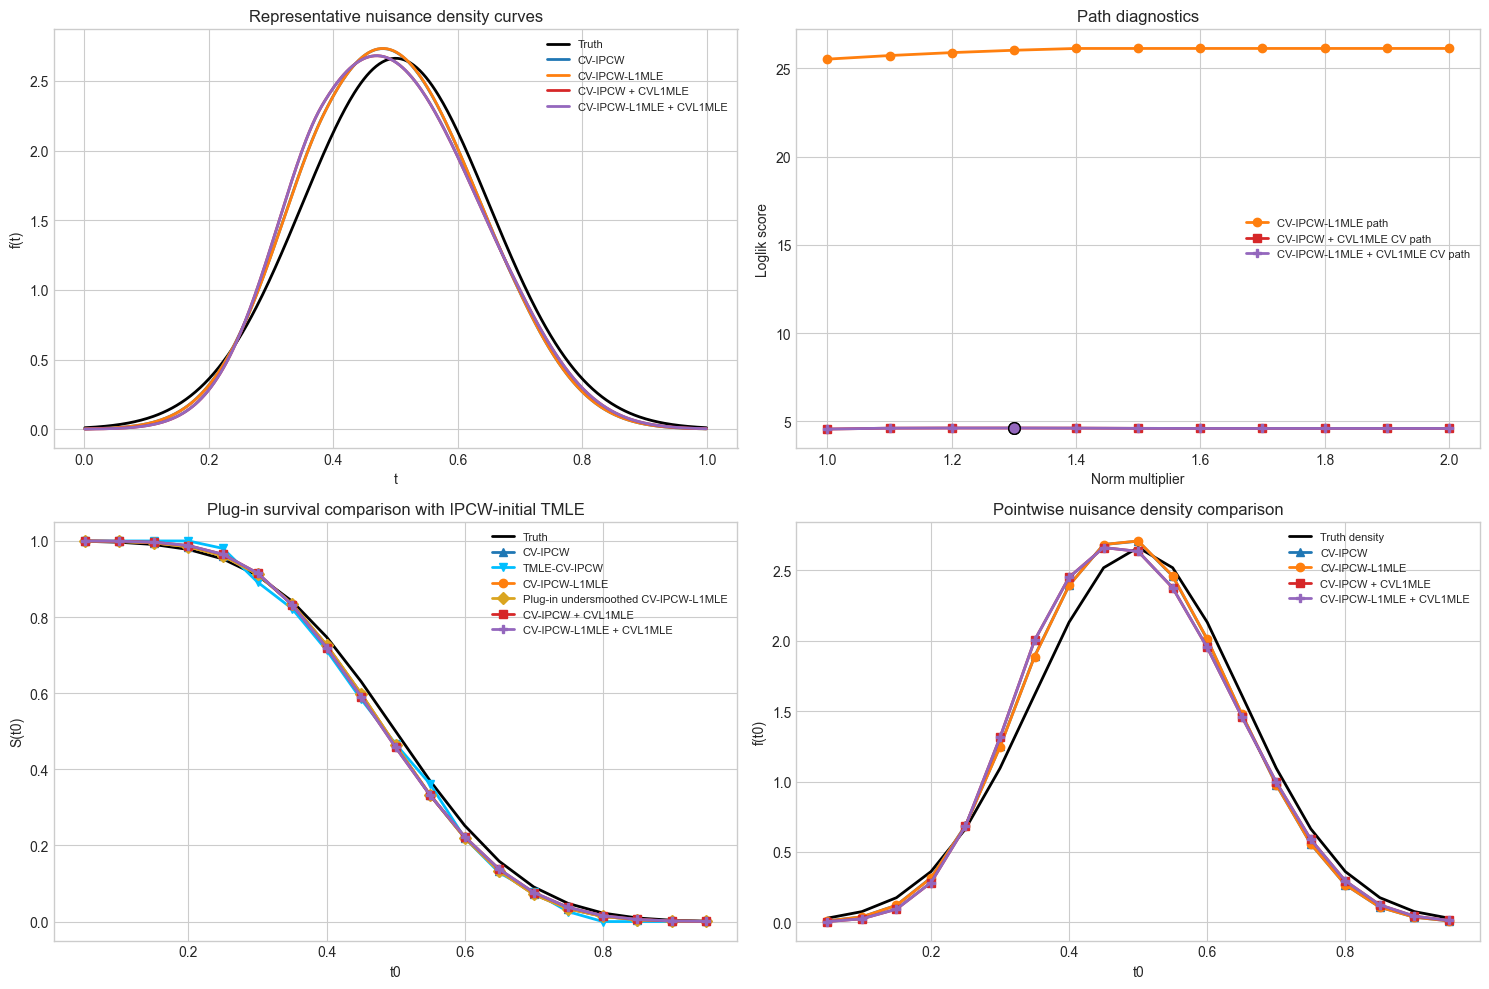

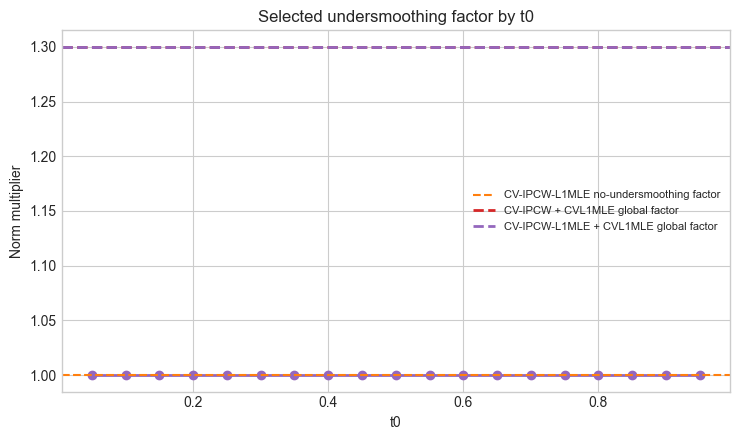

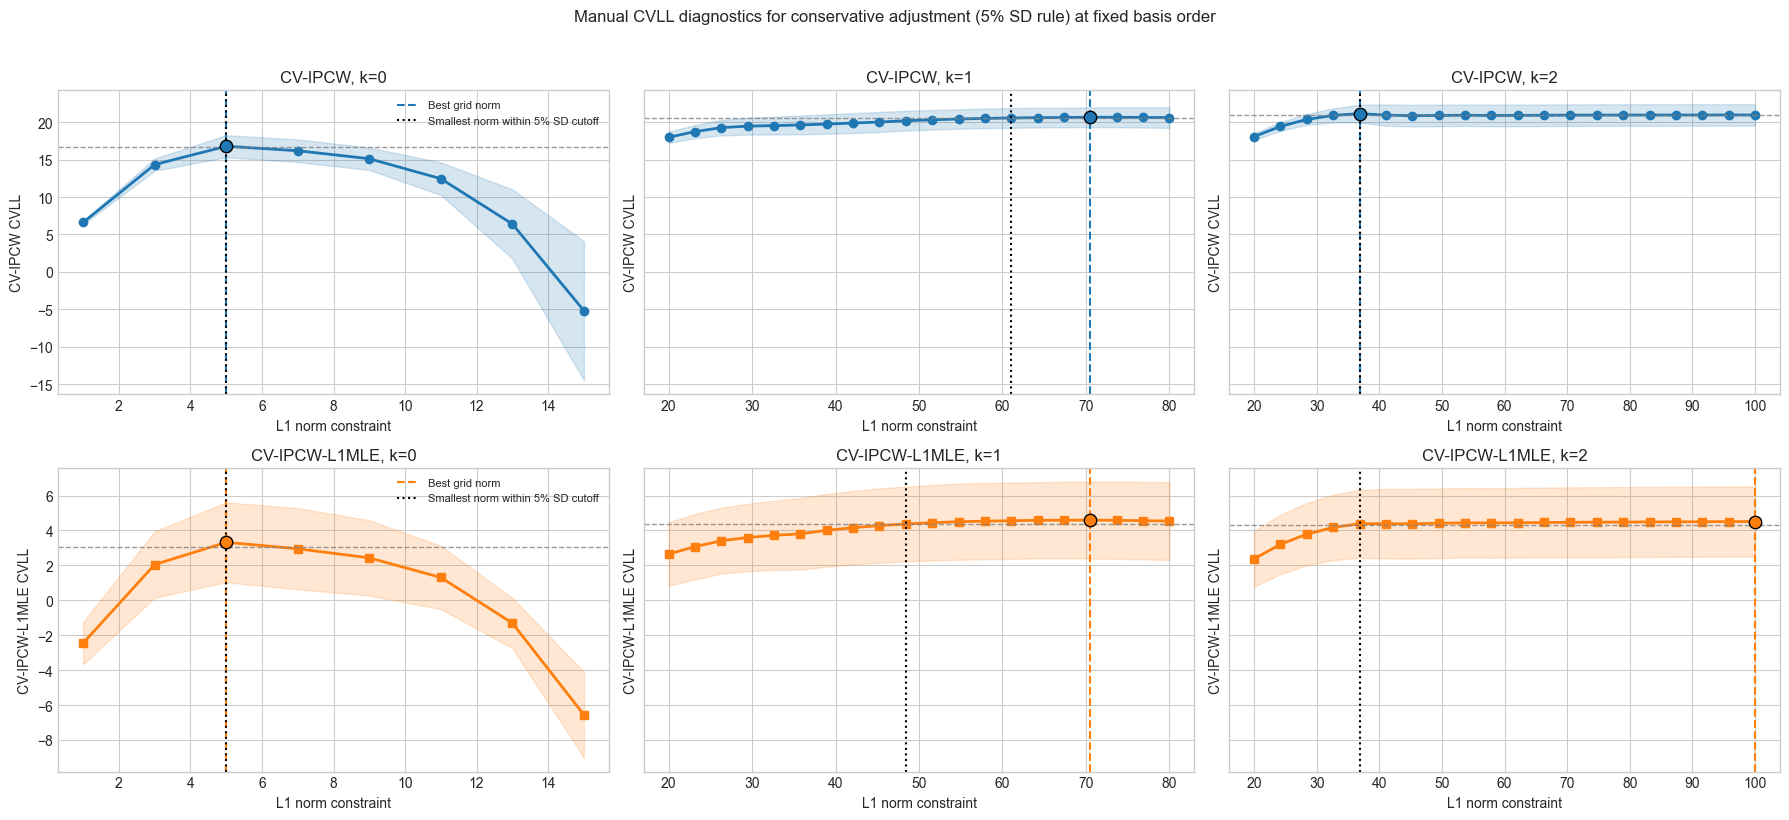

In [4]:
# Representative plots.

plot_grid = np.linspace(0.001, 0.999, 400)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(plot_grid, truth["density_fn"](plot_grid), color="black", linewidth=2, label="Truth")
axes[0, 0].plot(
    plot_grid,
    stage1_estimator.get_density_at_points(plot_grid),
    color="tab:blue",
    linewidth=2,
    label=CV_IPCW_METHOD,
)
axes[0, 0].plot(
    plot_grid,
    cv_ipcw_l1mle_no_undersmooth_run["estimator"].get_density_at_points(plot_grid),
    color="tab:orange",
    linewidth=2,
    label=CV_IPCW_L1MLE_METHOD,
)
axes[0, 0].plot(
    plot_grid,
    cvl1mle_fit["estimator"].get_density_at_points(plot_grid),
    color="tab:red",
    linewidth=2,
    label=CVL1MLE_METHOD,
)
axes[0, 0].plot(
    plot_grid,
    cvl1mle_after_cv_ipcw_l1mle_fit["estimator"].get_density_at_points(plot_grid),
    color="tab:purple",
    linewidth=2,
    label=CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
)
axes[0, 0].set_title("Representative nuisance density curves")
axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("f(t)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(
    cv_ipcw_l1mle_path["path_df"]["norm_factor"],
    cv_ipcw_l1mle_path["path_df"]["observed_loglik"],
    color="tab:orange",
    linewidth=2,
    marker="o",
    label="CV-IPCW-L1MLE path",
)
if not cvl1mle_fit["cv_path_df"].empty:
    axes[0, 1].plot(
        cvl1mle_fit["cv_path_df"]["norm_factor"],
        cvl1mle_fit["cv_path_df"]["mean_cv_loglik"],
        color="tab:red",
        linewidth=2,
        marker="s",
        label=f"{CVL1MLE_METHOD} CV path",
    )
    best_factor = float(cvl1mle_fit["best_norm_factor"])
    best_row = cvl1mle_fit["cv_path_df"][np.isclose(cvl1mle_fit["cv_path_df"]["norm_factor"], best_factor)]
    if not best_row.empty:
        axes[0, 1].scatter(best_row["norm_factor"], best_row["mean_cv_loglik"], color="tab:red", edgecolor="black", s=70, zorder=3)
if not cvl1mle_after_cv_ipcw_l1mle_fit["cv_path_df"].empty:
    axes[0, 1].plot(
        cvl1mle_after_cv_ipcw_l1mle_fit["cv_path_df"]["norm_factor"],
        cvl1mle_after_cv_ipcw_l1mle_fit["cv_path_df"]["mean_cv_loglik"],
        color="tab:purple",
        linewidth=2,
        marker="P",
        label=f"{CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD} CV path",
    )
    best_factor_after = float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"])
    best_row_after = cvl1mle_after_cv_ipcw_l1mle_fit["cv_path_df"][
        np.isclose(cvl1mle_after_cv_ipcw_l1mle_fit["cv_path_df"]["norm_factor"], best_factor_after)
    ]
    if not best_row_after.empty:
        axes[0, 1].scatter(
            best_row_after["norm_factor"],
            best_row_after["mean_cv_loglik"],
            color="tab:purple",
            edgecolor="black",
            s=70,
            zorder=3,
        )
axes[0, 1].set_title("Path diagnostics")
axes[0, 1].set_xlabel("Norm multiplier")
axes[0, 1].set_ylabel("Loglik score")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(
    representative_compare["t0"],
    representative_compare["truth_survival"],
    color="black",
    linewidth=2,
    label="Truth",
)
axes[1, 0].plot(
    representative_compare["t0"],
    representative_compare["plugin_survival_cv_ipcw"],
    color="tab:blue",
    linewidth=2,
    marker="^",
    label=CV_IPCW_METHOD,
)
axes[1, 0].plot(
    representative_compare["t0"],
    representative_compare["tmle_survival_cv_ipcw"],
    color="deepskyblue",
    linewidth=2,
    marker="v",
    label=TMLE_CV_IPCW_METHOD,
)
axes[1, 0].plot(
    representative_compare["t0"],
    representative_compare["plugin_survival_cv_ipcw_l1mle"],
    color="tab:orange",
    linewidth=2,
    marker="o",
    label=CV_IPCW_L1MLE_METHOD,
)
axes[1, 0].plot(
    representative_compare["t0"],
    representative_compare["plugin_survival_undersmoothed_cv_ipcw_l1mle"],
    color="goldenrod",
    linewidth=2,
    marker="D",
    label=US_CV_IPCW_L1MLE_METHOD,
)
axes[1, 0].plot(
    representative_compare["t0"],
    representative_compare["plugin_survival_cv_ipcw_plus_cvl1mle"],
    color="tab:red",
    linewidth=2,
    marker="s",
    label=CVL1MLE_METHOD,
)
axes[1, 0].plot(
    representative_compare["t0"],
    representative_compare["plugin_survival_cv_ipcw_l1mle_plus_cvl1mle"],
    color="tab:purple",
    linewidth=2,
    marker="P",
    label=CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
)
axes[1, 0].set_title("Plug-in survival comparison with IPCW-initial TMLE")
axes[1, 0].set_xlabel("t0")
axes[1, 0].set_ylabel("S(t0)")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(
    representative_compare["t0"],
    representative_compare["truth_density"],
    color="black",
    linewidth=2,
    label="Truth density",
)
axes[1, 1].plot(
    representative_compare["t0"],
    representative_compare["density_cv_ipcw"],
    color="tab:blue",
    linewidth=2,
    marker="^",
    label=CV_IPCW_METHOD,
)
axes[1, 1].plot(
    representative_compare["t0"],
    representative_compare["density_cv_ipcw_l1mle"],
    color="tab:orange",
    linewidth=2,
    marker="o",
    label=CV_IPCW_L1MLE_METHOD,
)
axes[1, 1].plot(
    representative_compare["t0"],
    representative_compare["density_cv_ipcw_plus_cvl1mle"],
    color="tab:red",
    linewidth=2,
    marker="s",
    label=CVL1MLE_METHOD,
)
axes[1, 1].plot(
    representative_compare["t0"],
    representative_compare["density_cv_ipcw_l1mle_plus_cvl1mle"],
    color="tab:purple",
    linewidth=2,
    marker="P",
    label=CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
)
axes[1, 1].set_title("Pointwise nuisance density comparison")
axes[1, 1].set_xlabel("t0")
axes[1, 1].set_ylabel("f(t0)")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    cv_ipcw_l1mle_selected["t0"],
    cv_ipcw_l1mle_selected["selected_norm_factor"],
    color="tab:purple",
    linewidth=2,
    marker="o",
)
ax.axhline(
    float(no_undersmooth_factor),
    color="tab:orange",
    linestyle="--",
    linewidth=1.5,
    label="CV-IPCW-L1MLE no-undersmoothing factor",
)
ax.axhline(
    float(cvl1mle_fit["best_norm_factor"]),
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=f"{CVL1MLE_METHOD} global factor",
)
ax.axhline(
    float(cvl1mle_after_cv_ipcw_l1mle_fit["best_norm_factor"]),
    color="tab:purple",
    linestyle="--",
    linewidth=2,
    label=f"{CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD} global factor",
)
ax.set_title("Selected undersmoothing factor by t0")
ax.set_xlabel("t0")
ax.set_ylabel("Norm multiplier")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

curve_style_map = {
    CV_IPCW_METHOD: {
        "color": "tab:blue",
        "mean_col": "mean_cv_ipcw_loglik",
        "sd_col": "sd_cv_ipcw_loglik",
        "n_col": "n_valid_stage1_folds",
        "marker": "o",
    },
    CV_IPCW_L1MLE_METHOD: {
        "color": "tab:orange",
        "mean_col": "mean_cv_ipcw_l1mle_loglik",
        "sd_col": "sd_cv_ipcw_l1mle_loglik",
        "n_col": "n_valid_refit_folds",
        "marker": "s",
    },
}

conservative_sd_fraction = 0.05

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey="row")
for col_idx, basis_order in enumerate(sorted(CVLL_GRID_BY_BASIS_ORDER)):
    subset = manual_cvll_curves["summary"][manual_cvll_curves["summary"]["basis_order"] == basis_order].copy()
    for row_idx, method in enumerate([CV_IPCW_METHOD, CV_IPCW_L1MLE_METHOD]):
        ax = axes[row_idx, col_idx]
        style = curve_style_map[method]
        mean_col = style["mean_col"]
        sd_col = style["sd_col"]
        n_col = style["n_col"]
        valid = subset[np.isfinite(subset[mean_col])].copy().sort_values("norm_constraint")
        if valid.empty:
            ax.set_title(f"k={basis_order}")
            ax.set_xlabel("L1 norm constraint")
            ax.set_ylabel(f"{method} CVLL")
            continue

        mean_values = valid[mean_col].to_numpy(dtype=float)
        sd_values = valid[sd_col].to_numpy(dtype=float)
        se_values = sd_values / np.sqrt(np.maximum(valid[n_col].to_numpy(dtype=float), 1.0))
        best_idx = int(np.nanargmax(mean_values))
        best_norm = float(valid.iloc[best_idx]["norm_constraint"])
        best_mean = float(mean_values[best_idx])
        best_sd = float(sd_values[best_idx])
        conservative_cutoff = best_mean - conservative_sd_fraction * best_sd
        conservative_rows = valid[valid[mean_col] >= conservative_cutoff - 1e-12].copy().sort_values("norm_constraint")
        conservative_norm = float(conservative_rows.iloc[0]["norm_constraint"])

        ax.plot(
            valid["norm_constraint"],
            valid[mean_col],
            color=style["color"],
            linewidth=2,
            marker=style["marker"],
        )
        ax.fill_between(
            valid["norm_constraint"],
            valid[mean_col] - se_values,
            valid[mean_col] + se_values,
            color=style["color"],
            alpha=0.18,
        )
        ax.axvline(best_norm, color=style["color"], linestyle="--", linewidth=1.5, label="Best grid norm")
        ax.axvline(
            conservative_norm,
            color="black",
            linestyle=":",
            linewidth=1.5,
            label="Smallest norm within 5% SD cutoff",
        )
        ax.axhline(conservative_cutoff, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
        ax.scatter(best_norm, best_mean, color=style["color"], edgecolor="black", s=80, zorder=3)
        ax.set_title(f"{method}, k={basis_order}")
        ax.set_xlabel("L1 norm constraint")
        ax.set_ylabel(f"{method} CVLL")
        if col_idx == 0:
            ax.legend(fontsize=8, loc="best")

plt.suptitle("Manual CVLL diagnostics for conservative adjustment (5% SD rule) at fixed basis order", y=1.02)
plt.tight_layout()
plt.show()


In [5]:
# Small-MC comparison: 50 reps, 8 workers.

seed_results = Parallel(n_jobs=N_WORKERS, backend="loky")(
    delayed(run_small_mc_seed)(seed) for seed in SMALL_MC_SEEDS
)

method_rows = [row for result in seed_results for row in result["method_rows"]]
pointwise_rows = [row for result in seed_results for row in result["pointwise_rows"]]
factor_rows = [row for result in seed_results for row in result["factor_rows"]]

method_summary = pd.DataFrame(method_rows)
pointwise_summary = pd.DataFrame(pointwise_rows)
factor_summary = pd.DataFrame(factor_rows)

method_order = {method: idx for idx, method in enumerate(RUNTIME_METHOD_ORDER)}

# Compare selected L1 norm constraints for the two CVL1MLE anchoring pipelines.
norm_choice_methods = [CVL1MLE_METHOD, CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD]
norm_choice_by_seed = (
    factor_summary[factor_summary["method"].isin(norm_choice_methods)]
    .groupby(["seed", "method"], as_index=False)
    .agg(selected_norm_constraint=("selected_norm_constraint", "median"))
)
norm_choice_overview = (
    norm_choice_by_seed.groupby("method", as_index=False)
    .agg(
        n_seeds=("seed", "size"),
        median_selected_norm_constraint=("selected_norm_constraint", "median"),
        min_selected_norm_constraint=("selected_norm_constraint", "min"),
        max_selected_norm_constraint=("selected_norm_constraint", "max"),
    )
    .sort_values("method", key=lambda s: s.map(method_order))
    .reset_index(drop=True)
)

runtime_overview = (
    method_summary.groupby("method", as_index=False)
    .agg(
        n_seeds=("seed", "size"),
        median_runtime_seconds=("runtime_seconds", "median"),
        median_mean_abs_survival_error=("mean_abs_error", "median"),
        median_mean_sq_survival_error=("mean_sq_error", "median"),
        median_mean_abs_density_error=("mean_density_abs_error", "median"),
        median_mean_sq_density_error=("mean_density_sq_error", "median"),
        median_selected_factor=("median_selected_factor", "median"),
        total_fallback_t0=("n_fallback_t0", "sum"),
    )
    .sort_values("method", key=lambda s: s.map(method_order))
    .reset_index(drop=True)
)

pointwise_metric_rows = []
for (method, estimand, eval_point), group in pointwise_summary.groupby(["method", "estimand", "eval_point"], sort=True):
    estimates = group["estimate"].to_numpy(dtype=float)
    truth_value = float(group["truth"].iloc[0])
    mean_estimate = float(np.mean(estimates))
    bias = float(mean_estimate - truth_value)
    variance = float(np.mean((estimates - mean_estimate) ** 2))
    mse = float(np.mean(np.square(estimates - truth_value)))
    pointwise_metric_rows.append(
        {
            "method": method,
            "estimand": estimand,
            "eval_point": float(eval_point),
            "truth": truth_value,
            "mean_estimate": mean_estimate,
            "bias": bias,
            "variance": variance,
            "mse": mse,
        }
    )

pointwise_metric_summary = pd.DataFrame(pointwise_metric_rows).sort_values(["estimand", "method", "eval_point"]).reset_index(drop=True)
pointwise_metric_overview = (
    pointwise_metric_summary.groupby(["method", "estimand"], as_index=False)
    .agg(
        mean_abs_bias=("bias", lambda s: float(np.mean(np.abs(np.asarray(s, dtype=float))))),
        mean_variance=("variance", "mean"),
        mean_mse=("mse", "mean"),
    )
    .sort_values("method", key=lambda s: s.map(method_order))
    .reset_index(drop=True)
)

cv_ipcw_l1mle_factor_by_t0 = (
    factor_summary[factor_summary["method"] == US_CV_IPCW_L1MLE_METHOD]
    .groupby("t0", as_index=False)
    .agg(
        median_selected_factor=("selected_norm_factor", "median"),
        min_selected_factor=("selected_norm_factor", "min"),
        max_selected_factor=("selected_norm_factor", "max"),
        n_fallback=("selection_status", lambda s: int(np.sum(np.asarray(s) == "closest_failing_factor"))),
    )
    .sort_values("t0")
    .reset_index(drop=True)
)

cvl1mle_factor_counts = (
    factor_summary[factor_summary["method"] == CVL1MLE_METHOD]
    .groupby("selected_norm_factor", as_index=False)
    .size()
    .rename(columns={"size": "n_seeds"})
    .sort_values("selected_norm_factor")
    .reset_index(drop=True)
)

cvl1mle_after_cv_ipcw_l1mle_factor_counts = (
    factor_summary[factor_summary["method"] == CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD]
    .groupby("selected_norm_factor", as_index=False)
    .size()
    .rename(columns={"size": "n_seeds"})
    .sort_values("selected_norm_factor")
    .reset_index(drop=True)
)

display(runtime_overview)
display(norm_choice_overview)
display(pointwise_metric_overview)
display(cv_ipcw_l1mle_factor_by_t0)
display(cvl1mle_factor_counts)
display(cvl1mle_after_cv_ipcw_l1mle_factor_counts)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True

,method,n_seeds,median_runtime_seconds,median_mean_abs_survival_error,median_mean_sq_survival_error,median_mean_abs_density_error,median_mean_sq_density_error,median_selected_factor,total_fallback_t0
0,CV-IPCW,50,6.642336,0.016755,0.000520,0.157207,0.042541,1.0,0
1,TMLE-CV-IPCW,50,6.778479,0.018797,0.000743,NaN,NaN,NaN,0
2,CV-IPCW-L1MLE,50,6.717462,0.015222,0.000454,0.150540,0.042427,1.0,0
3,Plug-in undersmoothed CV-IPCW-L1MLE,50,7.906589,0.015235,0.000455,NaN,NaN,1.0,0
4,CV-IPCW + CVL1MLE,50,7.858362,0.016107,0.000488,0.150540,0.039096,1.1,0
5,CV-IPCW-L1MLE + CVL1MLE,50,7.855093,0.016107,0.000488,0.150719,0.039095,1.1,0


,method,n_seeds,median_selected_norm_constraint,min_selected_norm_constraint,max_selected_norm_constraint
0,CV-IPCW + CVL1MLE,50,72.598158,3.761647,310.19025
1,CV-IPCW-L1MLE + CVL1MLE,50,72.598158,3.761647,310.19025


,method,estimand,mean_abs_bias,mean_variance,mean_mse
0,CV-IPCW,density,0.052879,0.100573,0.104773
1,CV-IPCW,survival,0.008068,0.001769,0.001879
2,TMLE-CV-IPCW,survival,0.001129,0.000886,0.000889
3,CV-IPCW-L1MLE,density,0.070313,0.097756,0.104403
4,CV-IPCW-L1MLE,survival,0.010048,0.001696,0.001826
5,Plug-in undersmoothed CV-IPCW-L1MLE,survival,0.010037,0.001697,0.001826
6,CV-IPCW + CVL1MLE,density,0.055286,0.097505,0.101870
7,CV-IPCW + CVL1MLE,survival,0.007705,0.001494,0.001571
8,CV-IPCW-L1MLE + CVL1MLE,density,0.055159,0.097499,0.101843
9,CV-IPCW-L1MLE + CVL1MLE,survival,0.007707,0.001495,0.001572


,t0,median_selected_factor,min_selected_factor,max_selected_factor,n_fallback
0,0.05,1.0,1.0,1.0,0
1,0.10,1.0,1.0,1.0,0
2,0.15,1.0,1.0,1.0,0
3,0.20,1.0,1.0,1.0,0
4,0.25,1.0,1.0,1.0,0
5,0.30,1.0,1.0,1.0,0
6,0.35,1.0,1.0,1.0,0
7,0.40,1.0,1.0,1.0,0
8,0.45,1.0,1.0,1.0,0
9,0.50,1.0,1.0,1.0,0


,selected_norm_factor,n_seeds
0,1.0,18
1,1.1,14
2,1.2,8
3,1.3,4
4,1.4,1
5,2.0,5


,selected_norm_factor,n_seeds
0,1.0,18
1,1.1,14
2,1.2,8
3,1.3,4
4,1.4,1
5,2.0,5


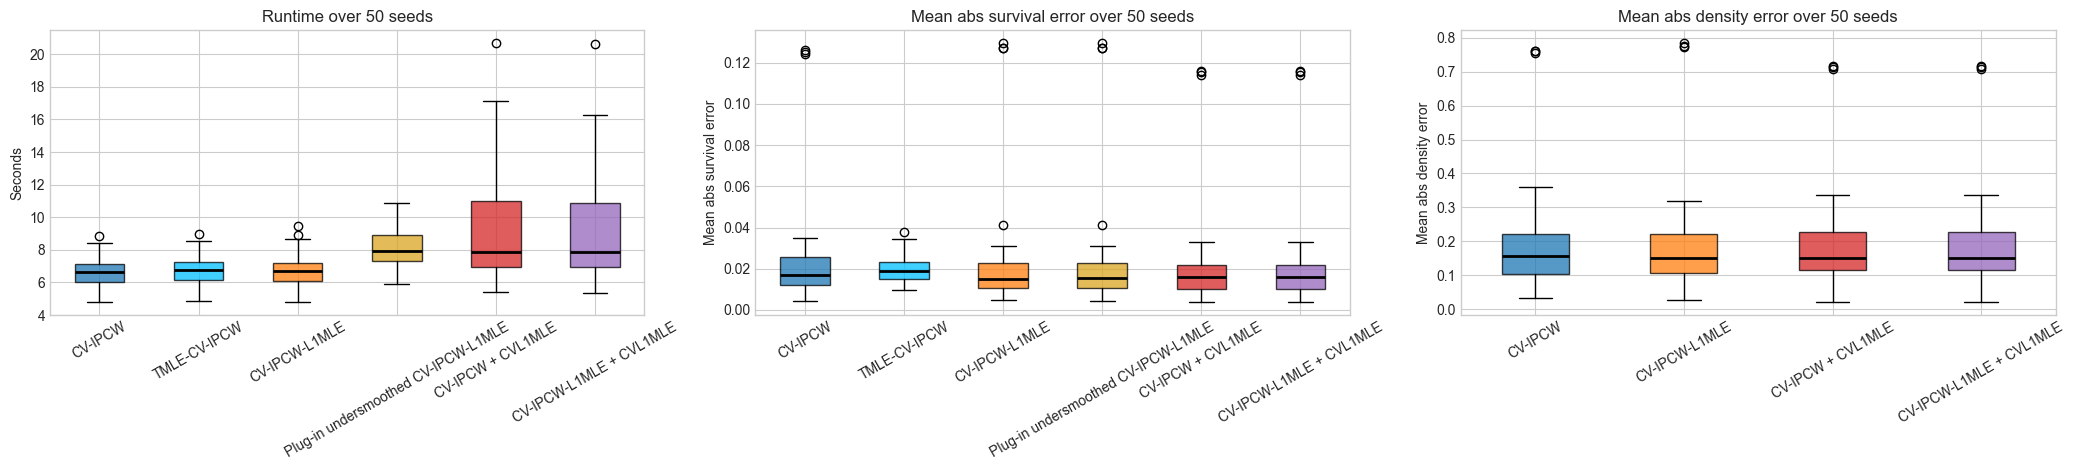

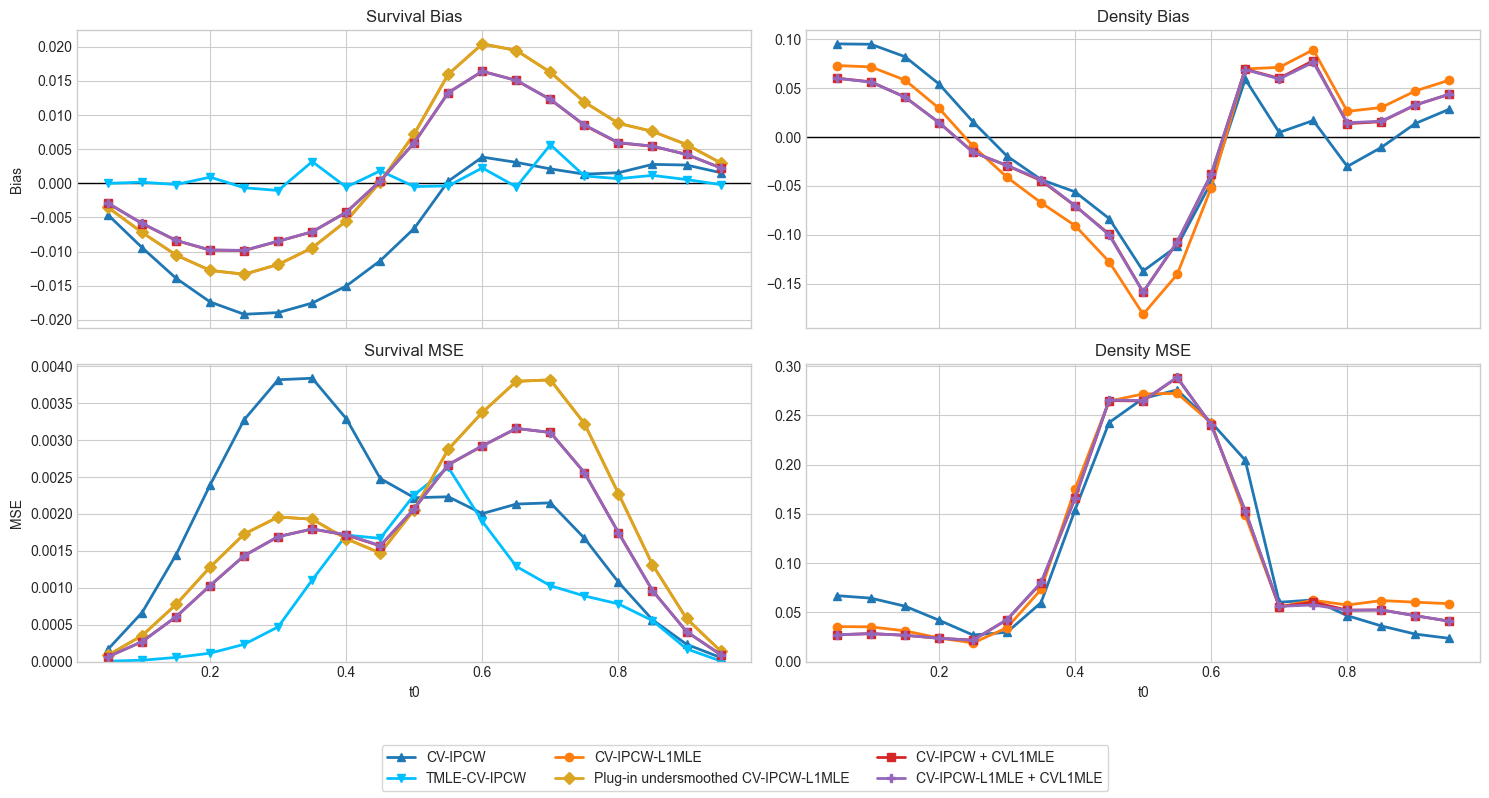

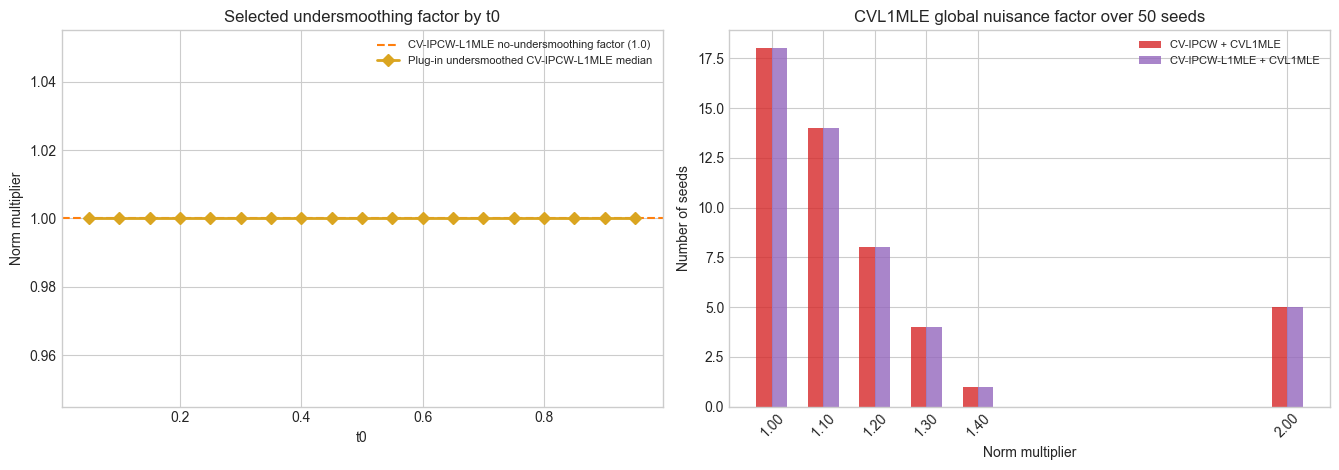

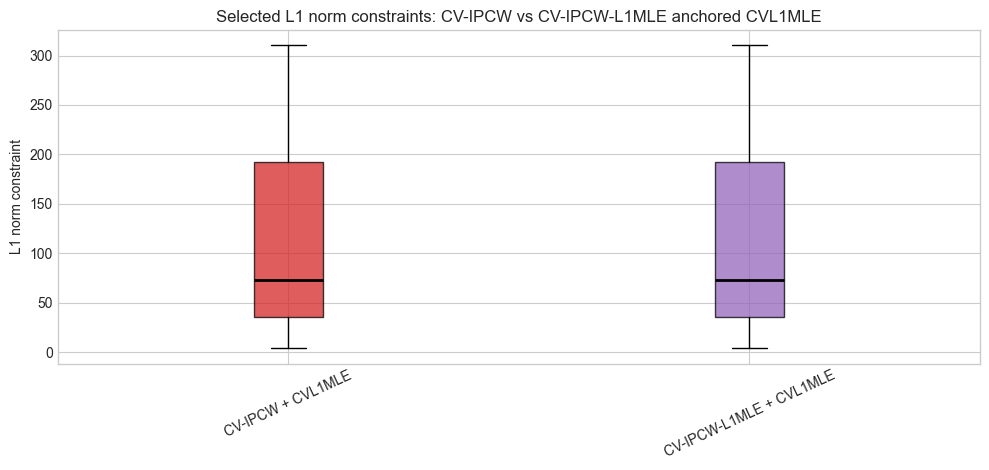

In [6]:
# Small-MC plots.

method_color_map = {
    CV_IPCW_METHOD: "tab:blue",
    TMLE_CV_IPCW_METHOD: "deepskyblue",
    CV_IPCW_L1MLE_METHOD: "tab:orange",
    US_CV_IPCW_L1MLE_METHOD: "goldenrod",
    CVL1MLE_METHOD: "tab:red",
    CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD: "tab:purple",
}

runtime_methods = list(RUNTIME_METHOD_ORDER)
survival_methods = list(SURVIVAL_METHOD_ORDER)
density_methods = list(DENSITY_METHOD_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(21, 4.8))

runtime_data = [
    method_summary.loc[method_summary["method"] == method, "runtime_seconds"].to_numpy(dtype=float)
    for method in runtime_methods
]
survival_error_data = [
    method_summary.loc[method_summary["method"] == method, "mean_abs_error"].dropna().to_numpy(dtype=float)
    for method in survival_methods
]
density_error_data = [
    method_summary.loc[method_summary["method"] == method, "mean_density_abs_error"].dropna().to_numpy(dtype=float)
    for method in density_methods
]

runtime_box = axes[0].boxplot(runtime_data, tick_labels=runtime_methods, patch_artist=True)
survival_error_box = axes[1].boxplot(survival_error_data, tick_labels=survival_methods, patch_artist=True)
density_error_box = axes[2].boxplot(density_error_data, tick_labels=density_methods, patch_artist=True)

for patch, method in zip(runtime_box["boxes"], runtime_methods):
    patch.set_facecolor(method_color_map[method])
    patch.set_alpha(0.75)
for patch, method in zip(survival_error_box["boxes"], survival_methods):
    patch.set_facecolor(method_color_map[method])
    patch.set_alpha(0.75)
for patch, method in zip(density_error_box["boxes"], density_methods):
    patch.set_facecolor(method_color_map[method])
    patch.set_alpha(0.75)
for boxplot in [runtime_box, survival_error_box, density_error_box]:
    for median in boxplot["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

axes[0].set_title("Runtime over 50 seeds")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=30)

axes[1].set_title("Mean abs survival error over 50 seeds")
axes[1].set_ylabel("Mean abs survival error")
axes[1].tick_params(axis="x", rotation=30)

axes[2].set_title("Mean abs density error over 50 seeds")
axes[2].set_ylabel("Mean abs density error")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

pointwise_plot_markers = {
    CV_IPCW_METHOD: "^",
    TMLE_CV_IPCW_METHOD: "v",
    CV_IPCW_L1MLE_METHOD: "o",
    US_CV_IPCW_L1MLE_METHOD: "D",
    CVL1MLE_METHOD: "s",
    CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD: "P",
}
metric_order = ["bias", "mse"]
estimand_order = ["survival", "density"]
metric_labels = {"bias": "Bias", "mse": "MSE"}
estimand_labels = {"survival": "Survival", "density": "Density"}

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for row_idx, metric in enumerate(metric_order):
    for col_idx, estimand in enumerate(estimand_order):
        ax = axes[row_idx, col_idx]
        if metric == "bias":
            ax.axhline(0.0, color="black", linewidth=1)
        panel_methods = survival_methods if estimand == "survival" else density_methods
        for method in panel_methods:
            sub = pointwise_metric_summary[
                (pointwise_metric_summary["method"] == method)
                & (pointwise_metric_summary["estimand"] == estimand)
            ].sort_values("eval_point")
            ax.plot(
                sub["eval_point"],
                sub[metric],
                linewidth=2,
                marker=pointwise_plot_markers[method],
                color=method_color_map[method],
                label=method,
            )
        ax.set_title(f"{estimand_labels[estimand]} {metric_labels[metric]}")
        if col_idx == 0:
            ax.set_ylabel(metric_labels[metric])
        if row_idx == len(metric_order) - 1:
            ax.set_xlabel("t0")
        if metric == "mse":
            ax.set_ylim(bottom=0.0)

legend_entries = {}
for ax in axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries[label] = handle
fig.legend(
    list(legend_entries.values()),
    list(legend_entries.keys()),
    loc="lower center",
    ncol=3,
    frameon=True,
)
plt.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
axes[0].axhline(
    1.0,
    color=method_color_map[CV_IPCW_L1MLE_METHOD],
    linestyle="--",
    linewidth=1.5,
    label="CV-IPCW-L1MLE no-undersmoothing factor (1.0)",
)
axes[0].plot(
    cv_ipcw_l1mle_factor_by_t0["t0"],
    cv_ipcw_l1mle_factor_by_t0["median_selected_factor"],
    color=method_color_map[US_CV_IPCW_L1MLE_METHOD],
    linewidth=2,
    marker="D",
    label="Plug-in undersmoothed CV-IPCW-L1MLE median",
)
axes[0].fill_between(
    cv_ipcw_l1mle_factor_by_t0["t0"],
    cv_ipcw_l1mle_factor_by_t0["min_selected_factor"],
    cv_ipcw_l1mle_factor_by_t0["max_selected_factor"],
    color=method_color_map[US_CV_IPCW_L1MLE_METHOD],
    alpha=0.2,
)
axes[0].set_title("Selected undersmoothing factor by t0")
axes[0].set_xlabel("t0")
axes[0].set_ylabel("Norm multiplier")
axes[0].legend(fontsize=8, loc="best")

bar_width = 0.03
base_factors = cvl1mle_factor_counts["selected_norm_factor"].to_numpy(dtype=float)
after_factors = cvl1mle_after_cv_ipcw_l1mle_factor_counts["selected_norm_factor"].to_numpy(dtype=float)

axes[1].bar(
    base_factors - bar_width / 2.0,
    cvl1mle_factor_counts["n_seeds"].to_numpy(dtype=float),
    width=bar_width,
    color=method_color_map[CVL1MLE_METHOD],
    alpha=0.8,
    label=CVL1MLE_METHOD,
)
axes[1].bar(
    after_factors + bar_width / 2.0,
    cvl1mle_after_cv_ipcw_l1mle_factor_counts["n_seeds"].to_numpy(dtype=float),
    width=bar_width,
    color=method_color_map[CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD],
    alpha=0.8,
    label=CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD,
)
factor_ticks = sorted({*base_factors.tolist(), *after_factors.tolist()})
axes[1].set_xticks(factor_ticks)
axes[1].set_xticklabels([f"{value:.2f}" for value in factor_ticks], rotation=45)
axes[1].set_title("CVL1MLE global nuisance factor over 50 seeds")
axes[1].set_xlabel("Norm multiplier")
axes[1].set_ylabel("Number of seeds")
axes[1].legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()

# Compare selected L1 norm constraints directly for the two CVL1MLE pipelines.
norm_boxplot_methods = [CVL1MLE_METHOD, CVL1MLE_AFTER_CV_IPCW_L1MLE_METHOD]
norm_boxplot_data = [
    norm_choice_by_seed.loc[
        norm_choice_by_seed["method"] == method,
        "selected_norm_constraint",
    ].to_numpy(dtype=float)
    for method in norm_boxplot_methods
]

fig, ax = plt.subplots(figsize=(10, 4.8))
norm_box = ax.boxplot(norm_boxplot_data, tick_labels=norm_boxplot_methods, patch_artist=True)

for patch, method in zip(norm_box["boxes"], norm_boxplot_methods):
    patch.set_facecolor(method_color_map[method])
    patch.set_alpha(0.75)
for median in norm_box["medians"]:
    median.set_color("black")
    median.set_linewidth(2)

ax.set_title("Selected L1 norm constraints: CV-IPCW vs CV-IPCW-L1MLE anchored CVL1MLE")
ax.set_ylabel("L1 norm constraint")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## Reading the Comparison

A few interpretation notes:

- `CV-IPCW`, `CV-IPCW-L1MLE`, `CV-IPCW + CVL1MLE`, and `CV-IPCW-L1MLE + CVL1MLE` are plug-in survival and density estimators.
- `Plug-in undersmoothed CV-IPCW-L1MLE` is a separate survival-only estimator that selects a larger factor along the `CV-IPCW-L1MLE` path using the iterative-TMLE EIF rule, then plugs in the selected fit for survival.
- `TMLE-CV-IPCW` is the only HAL-TMLE survival curve in this notebook.
- The density panels intentionally keep plug-in nuisance estimators only; undersmoothing is introduced for survival.
- The selected-factor summaries report how the undersmoothing selector moves away from factor `1.0` across `t0`.
- The manual `CVLL` panels are conservative-adjustment diagnostics: within each fixed `k`, they show how flat the CV curve is as the L1 norm changes.
- The shaded band is still `+/- 1` standard error across folds, while the dotted line marks the smallest norm whose mean CVLL stays within the shared `5% * SD` cutoff from the grid maximum.
- Those panels are still computed without Optuna: they use an explicit narrow grid in `M1` for each fixed `k`.
